## Для MATLAB

Spearman correlation: 0.9801
p-value: 0.0000e+00

Статистика Latent Risk по классам:

  Класс 0: средний риск = 14.73%
  Класс 1: средний риск = 27.11%
  Класс 2: средний риск = 41.51%
  Класс 3: средний риск = 56.02%
  Класс 4: средний риск = 69.76%
  Класс 5: средний риск = 83.13%

Детальная статистика:


Новый класс,Исходный класс,Среднее,Std,Медиана,25%,75%,Минимум,Максимум
0,0,14.73,4.59,13.64,11.82,16.71,0.00,40.42
1,1,27.11,4.04,26.76,24.69,29.14,11.11,55.78
2,2,41.51,4.19,41.35,39.14,43.83,24.03,59.54
3,3,56.02,4.30,56.19,53.74,58.56,34.71,74.54
4,4,69.76,4.50,70.31,67.51,72.62,42.65,88.18
5,5,83.13,4.49,83.78,80.91,85.96,58.35,100.00


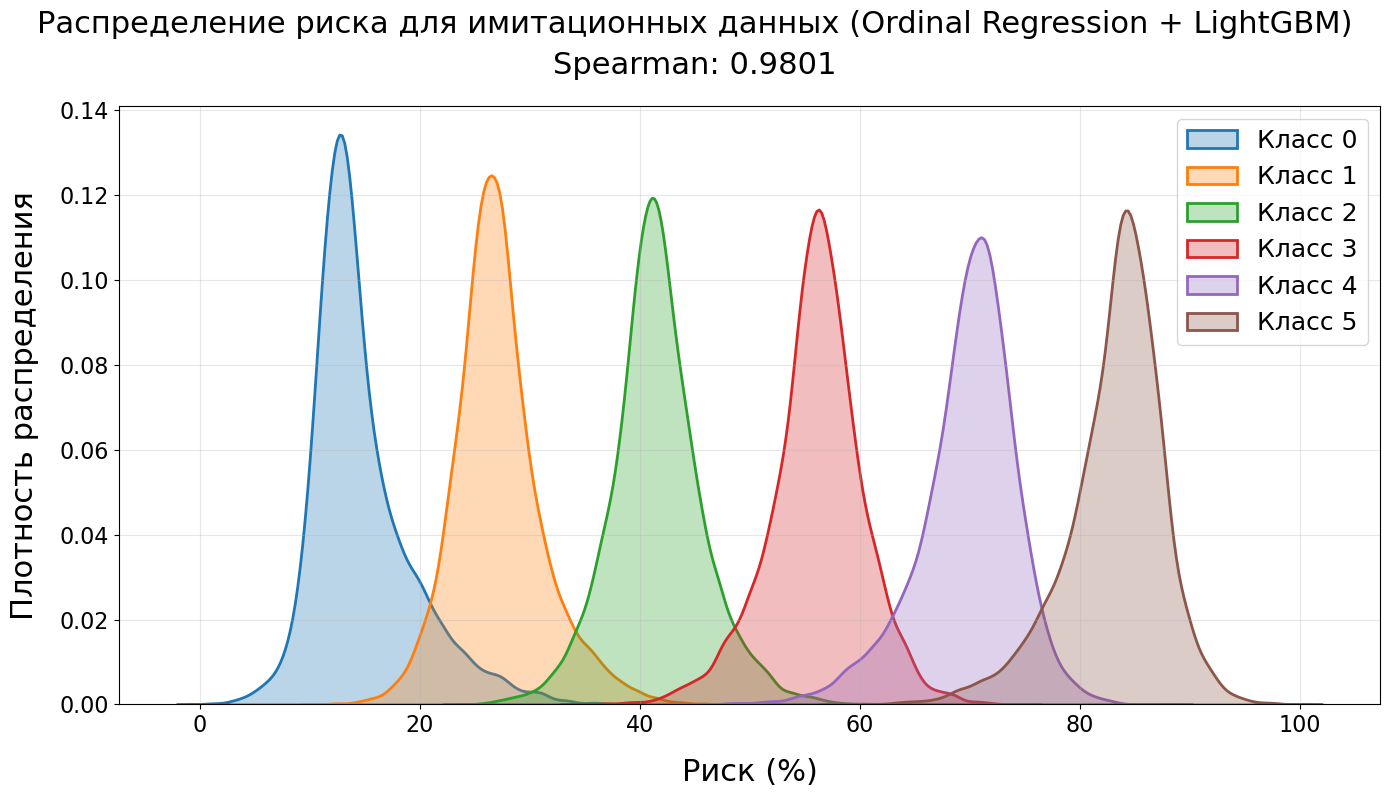

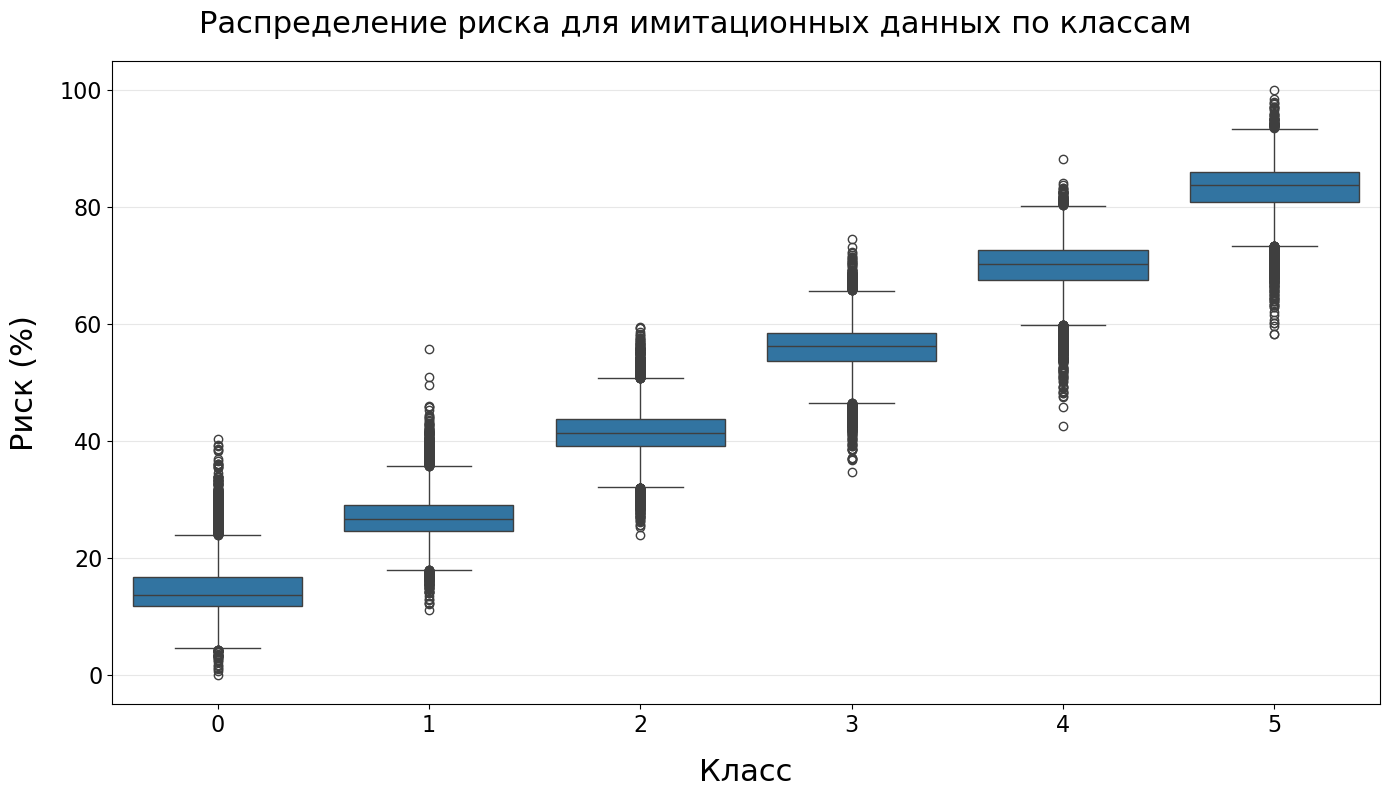

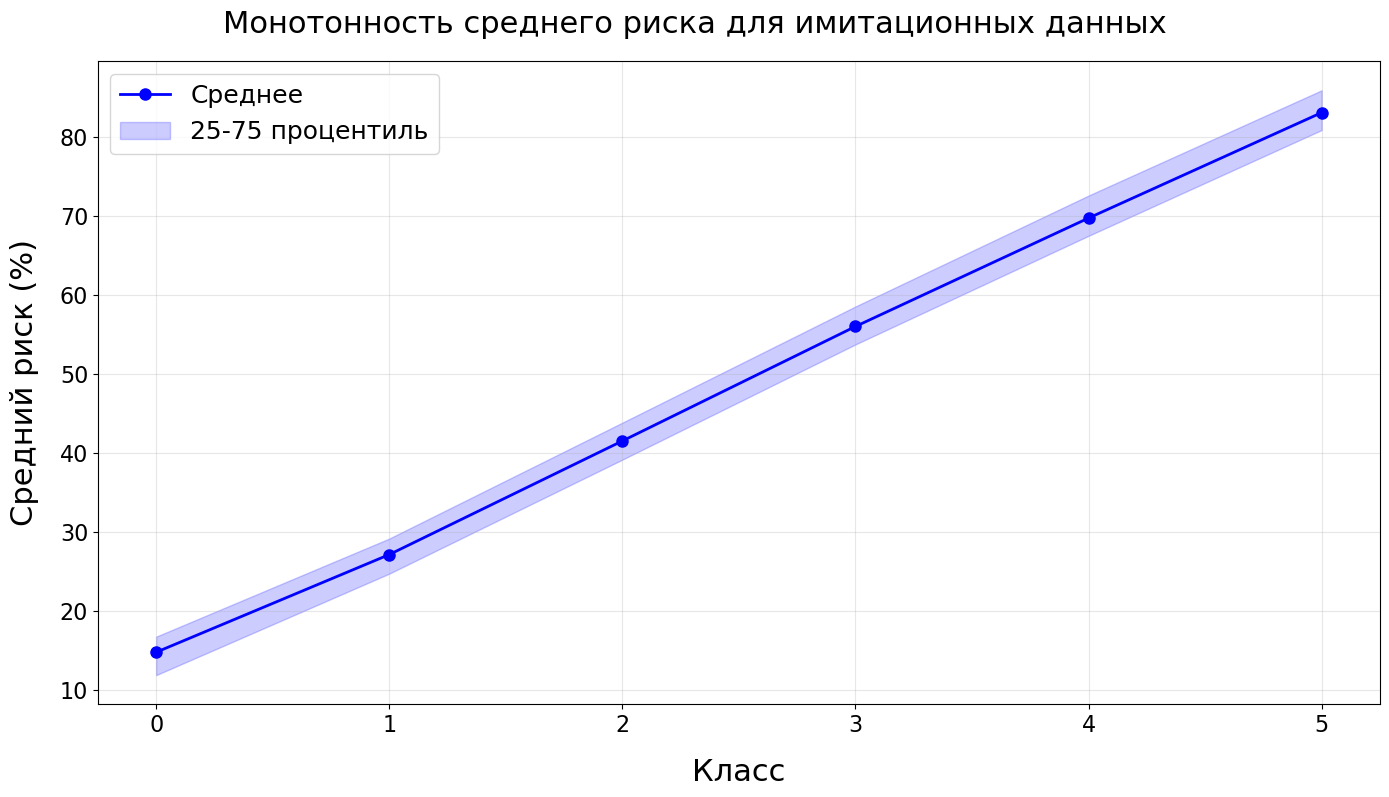

In [1]:
import json
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from lightgbm import LGBMRegressor


# ==================== ПАРАМЕТРЫ ====================
NUM_OF_FEATURES = 200
RANDOM_STATE = 42
NOISE_STD = 0.3
ALPHA = 0

# Фиксируем перестановку
fixed_perm = [0, 1, 2, 3, 4, 5]

np.random.seed(RANDOM_STATE)

# ==================== ДАННЫЕ ====================
features_df = pd.read_csv("DATA/features/MATLAB_features_ws256_overlap75.csv")

X = features_df.drop(columns=["Класс"]).to_numpy(dtype=np.float32)
y_raw = features_df["Класс"].to_numpy()

class_mapping = {val: i for i, val in enumerate(sorted(np.unique(y_raw), reverse=True))}
y = np.array([class_mapping[val] for val in y_raw])
n_classes = len(np.unique(y))

# ==================== МАППИНГ ====================
mapping = {old: new for new, old in enumerate(fixed_perm)}
inverse_mapping = {v: k for k, v in mapping.items()}
y_mapped = np.array([mapping[v] for v in y])

# ==================== SCALER ====================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# =========================================================
# ORDINAL БЛОК 
# =========================================================
ordinal_models = []

for k in range(1, n_classes):
    y_binary = (y_mapped >= k).astype(int)

    clf = LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    )
    clf.fit(X_scaled, y_binary)
    ordinal_models.append(clf)

ordinal_all = np.mean(
    [m.decision_function(X_scaled) for m in ordinal_models],
    axis=0
)

o_min, o_max = ordinal_all.min(), ordinal_all.max()
ordinal_all_n = (ordinal_all - o_min) / (o_max - o_min)


# =========================================================
# REGRESSION БЛОК 
# =========================================================
y_reg = y_mapped.astype(float) + np.random.normal(
    0, NOISE_STD, size=len(y_mapped)
)

reg_model = LGBMRegressor(
    n_estimators=400,
    max_depth=10,
    random_state=RANDOM_STATE,
    verbose=-1
)

reg_model.fit(X, y_reg)

reg_all = reg_model.predict(X)

r_min, r_max = reg_all.min(), reg_all.max()
reg_all_n = (reg_all - r_min) / (r_max - r_min)


# =========================================================
# HYBRID 
# =========================================================
risk_all = 100 * (ALPHA * ordinal_all_n + (1 - ALPHA) * reg_all_n)
risk_all = np.clip(risk_all, 0, 100)

spearman_corr, p_value = spearmanr(risk_all, y_mapped)

print(f"Spearman correlation: {spearman_corr:.4f}")
print(f"p-value: {p_value:.4e}")

print("\nСтатистика Latent Risk по классам:\n")

stats = []

for new_class in range(n_classes):
    data = risk_all[y_mapped == new_class]
    old_class = inverse_mapping[new_class]

    mean_val = np.mean(data)

    stats.append({
        'Новый класс': new_class,
        'Исходный класс': old_class,
        'Среднее': mean_val,
        'Std': np.std(data),
        'Медиана': np.median(data),
        '25%': np.percentile(data, 25),
        '75%': np.percentile(data, 75),
        'Минимум': np.min(data),
        'Максимум': np.max(data)
    })

    print(f"  Класс {new_class}: средний риск = {mean_val:.2f}%")

stats_df = pd.DataFrame(stats)
print("\nДетальная статистика:")
display(stats_df.style.hide(axis='index').format({
    'Среднее': '{:.2f}',
    'Std': '{:.2f}',
    'Медиана': '{:.2f}',
    '25%': '{:.2f}',
    '75%': '{:.2f}',
    'Минимум': '{:.2f}',
    'Максимум': '{:.2f}'
}))

# ==================== ГРАФИК 1: KDE распределение ====================

fig = plt.figure(figsize=(14, 8))
for new_class in range(n_classes):
    data = risk_all[y_mapped == new_class]
    old_class = inverse_mapping[new_class]
    
    sns.kdeplot(
        data,
        label=f'Класс {new_class}',
        fill=True,
        alpha=0.3,
        linewidth=2
    )
plt.xlabel("Риск (%)", fontsize=22, fontweight='medium', labelpad=15)
plt.ylabel("Плотность распределения", fontsize=22, fontweight='medium', labelpad=15)
fig.suptitle(f"Распределение риска для имитационных данных (Ordinal Regression + LightGBM)\nSpearman: {spearman_corr:.4f}", fontsize=22, y=0.99, fontweight="medium", linespacing=1.5)
plt.legend(loc='upper right', fontsize=18)
plt.grid(alpha=0.3)
plt.tick_params(axis='x', labelsize=16)
plt.tick_params(axis='y', labelsize=16)
plt.tight_layout()
# plt.savefig('APPLICATIONS/risk_distribution_xgb.png', dpi=600, bbox_inches='tight')
plt.show()

# ==================== ГРАФИК 2: Boxplot ====================

fig = plt.figure(figsize=(14, 8))

data_for_box = []
labels_for_box = []

for new_class in range(n_classes):
    data_for_box.extend(risk_all[y_mapped == new_class])
    old_class = inverse_mapping[new_class]
    labels_for_box.extend(
        [f'{new_class}'] * sum(y_mapped == new_class)
    )

df_box = pd.DataFrame({'Класс': labels_for_box, 'Риск': data_for_box})

sns.boxplot(data=df_box, x='Класс', y='Риск')

fig.suptitle('Распределение риска для имитационных данных по классам', fontsize=22, y=0.99, fontweight="medium")
plt.ylabel('Риск (%)', fontsize=22, fontweight='medium', labelpad=15)
plt.xlabel('Класс', fontsize=22, fontweight='medium', labelpad=15)
plt.grid(alpha=0.3, axis='y')
plt.tick_params(axis='x', labelsize=16)
plt.tick_params(axis='y', labelsize=16)
plt.tight_layout()
# plt.savefig('APPLICATIONS/risk_boxplot_xgb.png', dpi=600, bbox_inches='tight')
plt.show()

# ==================== ГРАФИК 3: Монотонность среднего риска ====================

fig = plt.figure(figsize=(14, 8))

means = [np.mean(risk_all[y_mapped == c]) for c in range(n_classes)]
new_classes = range(n_classes)
old_labels = [f"{c}\n({inverse_mapping[c]})" for c in new_classes]

plt.plot(new_classes, means, 'o-', linewidth=2, markersize=8, color='blue', label='Среднее')

# Добавляем доверительный интервал (25-75 процентили)
plt.fill_between(
    new_classes,
    [np.percentile(risk_all[y_mapped == c], 25) for c in new_classes],
    [np.percentile(risk_all[y_mapped == c], 75) for c in new_classes],
    alpha=0.2,
    color='blue',
    label='25-75 процентиль'
)

# plt.xticks(new_classes, old_labels)
plt.xlabel('Класс', fontsize=22, fontweight='medium', labelpad=15)
plt.ylabel('Средний риск (%)', fontsize=22, fontweight='medium', labelpad=15)
fig.suptitle('Монотонность среднего риска для имитационных данных', fontsize=22, y=0.99, fontweight="medium")
plt.grid(alpha=0.3)
plt.legend(loc='upper left', fontsize=18)
plt.tick_params(axis='x', labelsize=16)
plt.tick_params(axis='y', labelsize=16)
plt.tight_layout()
# plt.savefig('APPLICATIONS/risk_monotonicity_xgb.png', dpi=600, bbox_inches='tight')
plt.show()


Размер первого датасета: (283108, 1057)
Размер второго датасета: (23438, 1057)
Размер объединенного датасета: (306546, 1057)
Spearman correlation: 0.9720
p-value: 0.0000e+00

Статистика Latent Risk по классам:

  Класс 0: средний риск = 18.52%
  Класс 1: средний риск = 29.74%
  Класс 2: средний риск = 42.66%
  Класс 3: средний риск = 55.93%
  Класс 4: средний риск = 68.56%
  Класс 5: средний риск = 80.39%

Детальная статистика:
 Новый класс  Исходный класс   Среднее      Std   Медиана       25%       75%   Минимум   Максимум
           0               0 18.524204 5.599653 16.789505 15.059305 20.420050  0.000000  59.217708
           1               1 29.743900 4.516685 29.087867 27.211759 31.516000 10.376781  63.074389
           2               2 42.657572 4.341742 42.556086 40.417610 44.813688 19.888413  71.146008
           3               3 55.929642 4.562206 56.185955 53.790905 58.476108 25.495300  79.742537
           4               4 68.556288 5.054885 69.433839 66.466134 71.57

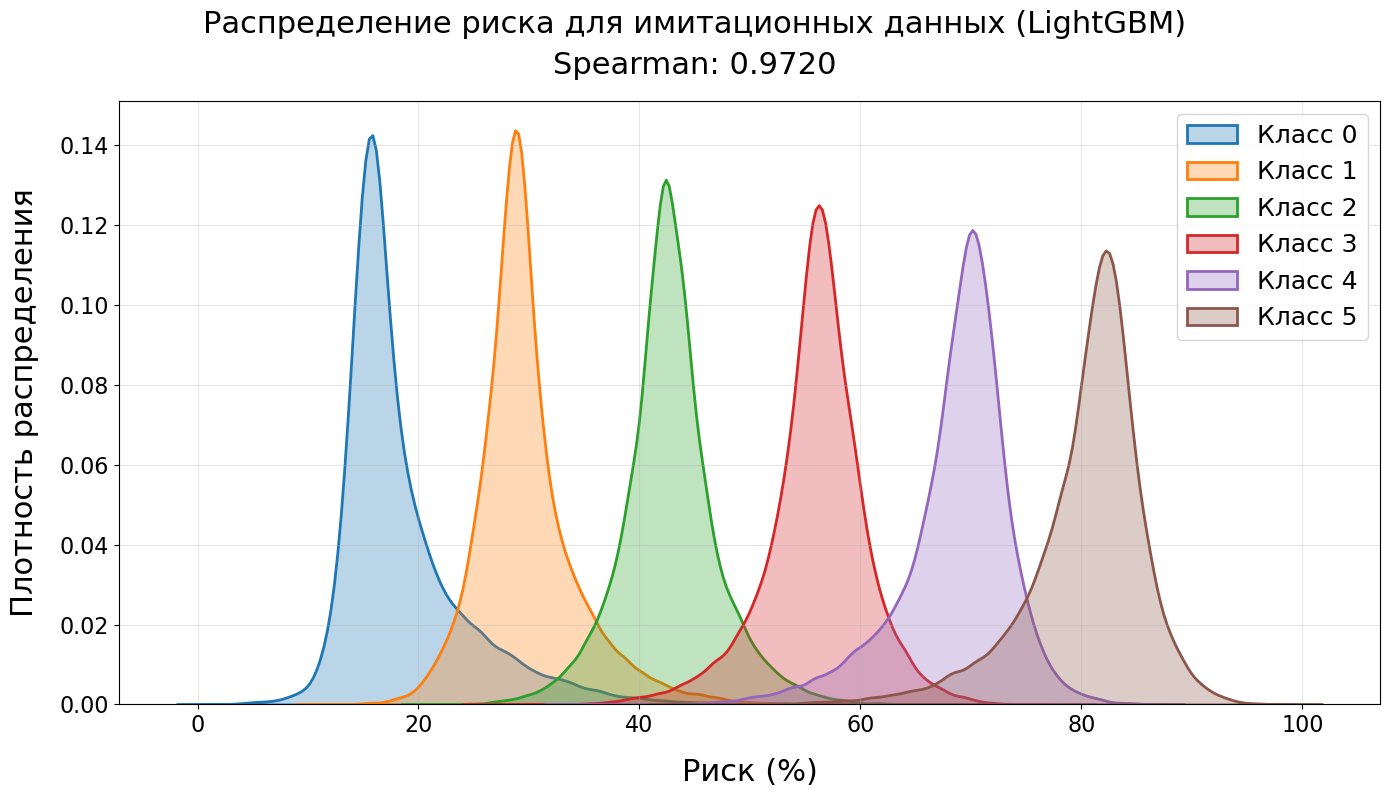

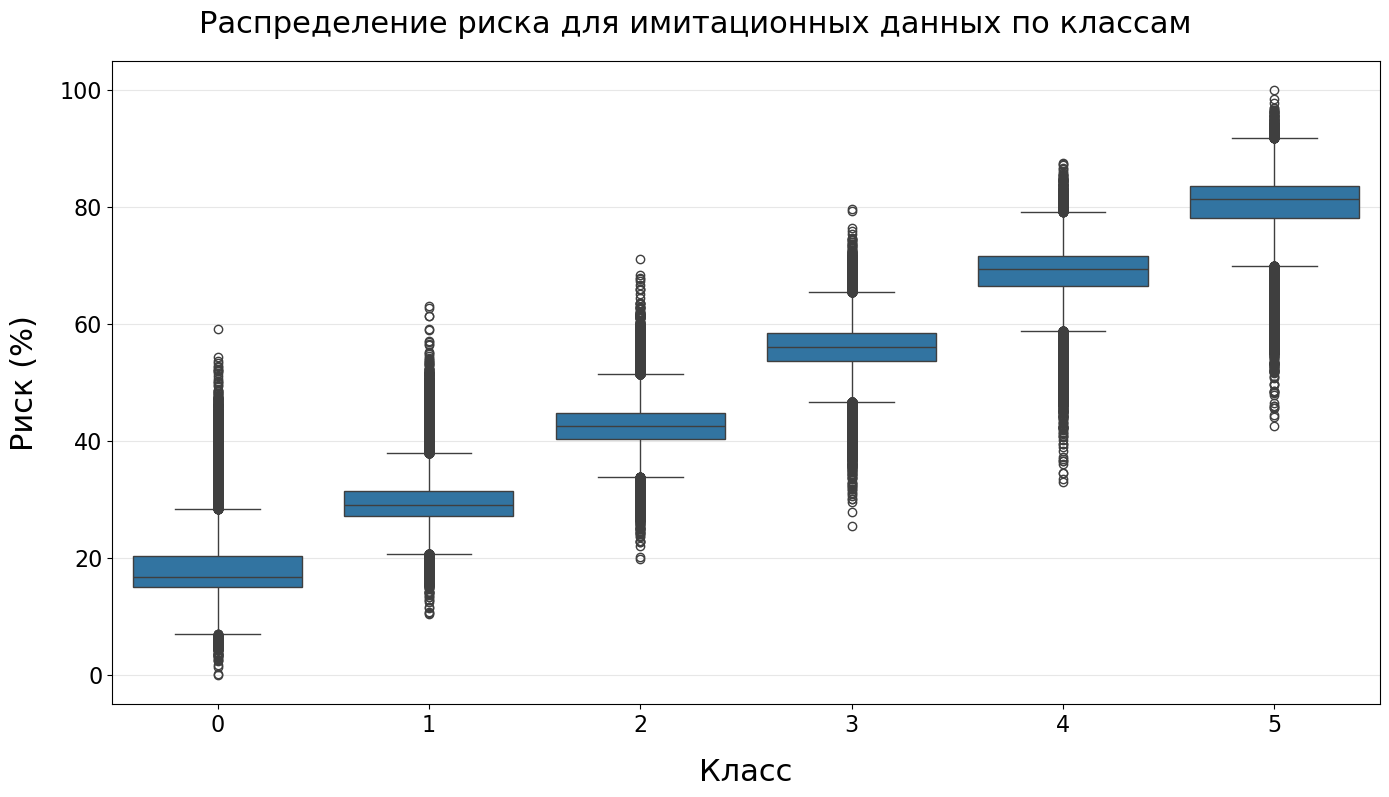

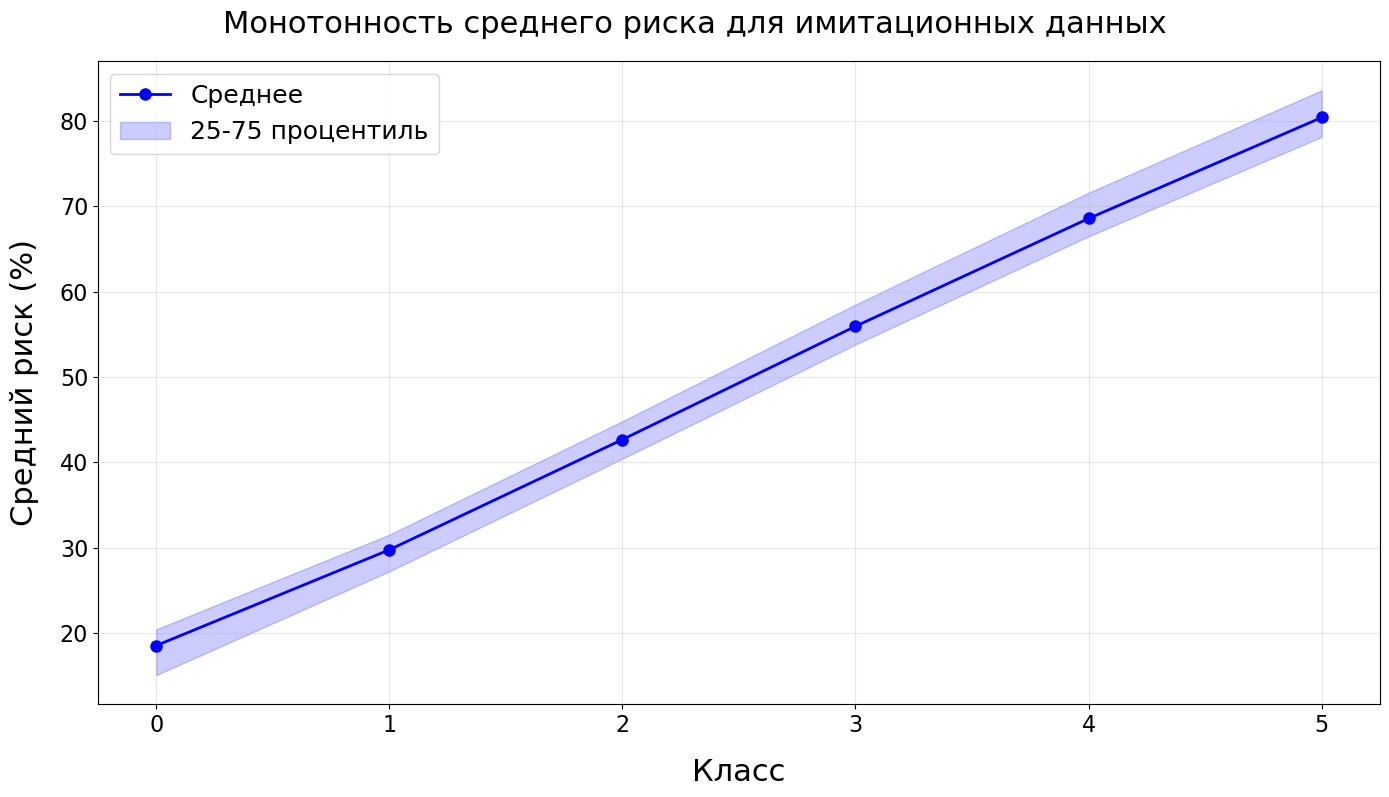

In [2]:
import json
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

from sklearn.preprocessing import StandardScaler

from lightgbm import LGBMRegressor


# ==================== ПАРАМЕТРЫ ====================
NUM_OF_FEATURES = 200
RANDOM_STATE = 42
NOISE_STD = 0.3

# Фиксируем перестановку
fixed_perm = [0, 1, 2, 3, 4, 5]

np.random.seed(RANDOM_STATE)

# ==================== ДАННЫЕ ====================
features_df_1 = pd.read_csv("DATA/features/MATLAB_features_ws64_overlap75.csv")
features_df_2 = pd.read_csv(f"DATA/features_test_flight/MATLAB_TEST_features_ws64_overlap75.csv")
features_df = pd.concat([features_df_1, features_df_2], axis=0, ignore_index=True)

print(f"Размер первого датасета: {features_df_1.shape}")
print(f"Размер второго датасета: {features_df_2.shape}")
print(f"Размер объединенного датасета: {features_df.shape}")

X = features_df.drop(columns=["Класс"]).to_numpy(dtype=np.float32)
y_raw = features_df["Класс"].to_numpy()

class_mapping = {val: i for i, val in enumerate(sorted(np.unique(y_raw), reverse=True))}
y = np.array([class_mapping[val] for val in y_raw])
n_classes = len(np.unique(y))

# ==================== МАППИНГ ====================
mapping = {old: new for new, old in enumerate(fixed_perm)}
inverse_mapping = {v: k for k, v in mapping.items()}
y_mapped = np.array([mapping[v] for v in y])

# ==================== SCALER ====================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# =========================================================
# REGRESSION БЛОК 
# =========================================================
y_reg = y_mapped.astype(float) + np.random.normal(
    0, NOISE_STD, size=len(y_mapped)
)

reg_model = LGBMRegressor(
    n_estimators=400,
    max_depth=10,
    random_state=RANDOM_STATE,
    verbose=-1
)

reg_model.fit(X_scaled, y_reg)

reg_all = reg_model.predict(X_scaled)

r_min, r_max = reg_all.min(), reg_all.max()
reg_all_n = (reg_all - r_min) / (r_max - r_min)


# =========================================================
# РИСК (только регрессия, alpha не используется)
# =========================================================
risk_all = 100 * reg_all_n
risk_all = np.clip(risk_all, 0, 100)

spearman_corr, p_value = spearmanr(risk_all, y_mapped)

print(f"Spearman correlation: {spearman_corr:.4f}")
print(f"p-value: {p_value:.4e}")

print("\nСтатистика Latent Risk по классам:\n")

stats = []

for new_class in range(n_classes):
    data = risk_all[y_mapped == new_class]
    old_class = inverse_mapping[new_class]

    mean_val = np.mean(data)

    stats.append({
        'Новый класс': new_class,
        'Исходный класс': old_class,
        'Среднее': mean_val,
        'Std': np.std(data),
        'Медиана': np.median(data),
        '25%': np.percentile(data, 25),
        '75%': np.percentile(data, 75),
        'Минимум': np.min(data),
        'Максимум': np.max(data)
    })

    print(f"  Класс {new_class}: средний риск = {mean_val:.2f}%")

stats_df = pd.DataFrame(stats)
print("\nДетальная статистика:")
print(stats_df.to_string(index=False))

# ==================== ГРАФИК 1: KDE распределение ====================

fig = plt.figure(figsize=(14, 8))
for new_class in range(n_classes):
    data = risk_all[y_mapped == new_class]
    old_class = inverse_mapping[new_class]
    
    sns.kdeplot(
        data,
        label=f'Класс {new_class}',
        fill=True,
        alpha=0.3,
        linewidth=2
    )
plt.xlabel("Риск (%)", fontsize=22, fontweight='medium', labelpad=15)
plt.ylabel("Плотность распределения", fontsize=22, fontweight='medium', labelpad=15)
fig.suptitle(f"Распределение риска для имитационных данных (LightGBM)\nSpearman: {spearman_corr:.4f}", fontsize=22, y=0.99, fontweight="medium", linespacing=1.5)
plt.legend(loc='upper right', fontsize=18)
plt.grid(alpha=0.3)
plt.tick_params(axis='x', labelsize=16)
plt.tick_params(axis='y', labelsize=16)
plt.tight_layout()
# plt.savefig('APPLICATIONS/risk_distribution_xgb.png', dpi=600, bbox_inches='tight')
plt.show()

# ==================== ГРАФИК 2: Boxplot ====================

fig = plt.figure(figsize=(14, 8))

data_for_box = []
labels_for_box = []

for new_class in range(n_classes):
    data_for_box.extend(risk_all[y_mapped == new_class])
    old_class = inverse_mapping[new_class]
    labels_for_box.extend(
        [f'{new_class}'] * sum(y_mapped == new_class)
    )

df_box = pd.DataFrame({'Класс': labels_for_box, 'Риск': data_for_box})

sns.boxplot(data=df_box, x='Класс', y='Риск')

fig.suptitle('Распределение риска для имитационных данных по классам', fontsize=22, y=0.99, fontweight="medium")
plt.ylabel('Риск (%)', fontsize=22, fontweight='medium', labelpad=15)
plt.xlabel('Класс', fontsize=22, fontweight='medium', labelpad=15)
plt.grid(alpha=0.3, axis='y')
plt.tick_params(axis='x', labelsize=16)
plt.tick_params(axis='y', labelsize=16)
plt.tight_layout()
# plt.savefig('APPLICATIONS/risk_boxplot_xgb.png', dpi=600, bbox_inches='tight')
plt.show()

# ==================== ГРАФИК 3: Монотонность среднего риска ====================

fig = plt.figure(figsize=(14, 8))

means = [np.mean(risk_all[y_mapped == c]) for c in range(n_classes)]
new_classes = range(n_classes)
old_labels = [f"{c}\n({inverse_mapping[c]})" for c in new_classes]

plt.plot(new_classes, means, 'o-', linewidth=2, markersize=8, color='blue', label='Среднее')

# Добавляем доверительный интервал (25-75 процентили)
plt.fill_between(
    new_classes,
    [np.percentile(risk_all[y_mapped == c], 25) for c in new_classes],
    [np.percentile(risk_all[y_mapped == c], 75) for c in new_classes],
    alpha=0.2,
    color='blue',
    label='25-75 процентиль'
)

# plt.xticks(new_classes, old_labels)
plt.xlabel('Класс', fontsize=22, fontweight='medium', labelpad=15)
plt.ylabel('Средний риск (%)', fontsize=22, fontweight='medium', labelpad=15)
fig.suptitle('Монотонность среднего риска для имитационных данных', fontsize=22, y=0.99, fontweight="medium")
plt.grid(alpha=0.3)
plt.legend(loc='upper left', fontsize=18)
plt.tick_params(axis='x', labelsize=16)
plt.tick_params(axis='y', labelsize=16)
plt.tight_layout()
# plt.savefig('APPLICATIONS/risk_monotonicity_xgb.png', dpi=600, bbox_inches='tight')
plt.show()

# with open('MATLAB_regression_model_t.pkl', 'wb') as f:
#     pickle.dump(reg_model, f)

# with open('MATLAB_standard_scaler_reg_model_t.pkl', 'wb') as f:
#     pickle.dump(scaler, f)

# print("r_min:", r_min, "r_max:", r_max)

# minimal_save = {
#     'model': reg_model,
#     'scaler': scaler,
#     'r_min': r_min,
#     'r_max': r_max
# }

# with open('MATLAB_risk_all_t.pkl', 'wb') as f:
#     pickle.dump(minimal_save, f)

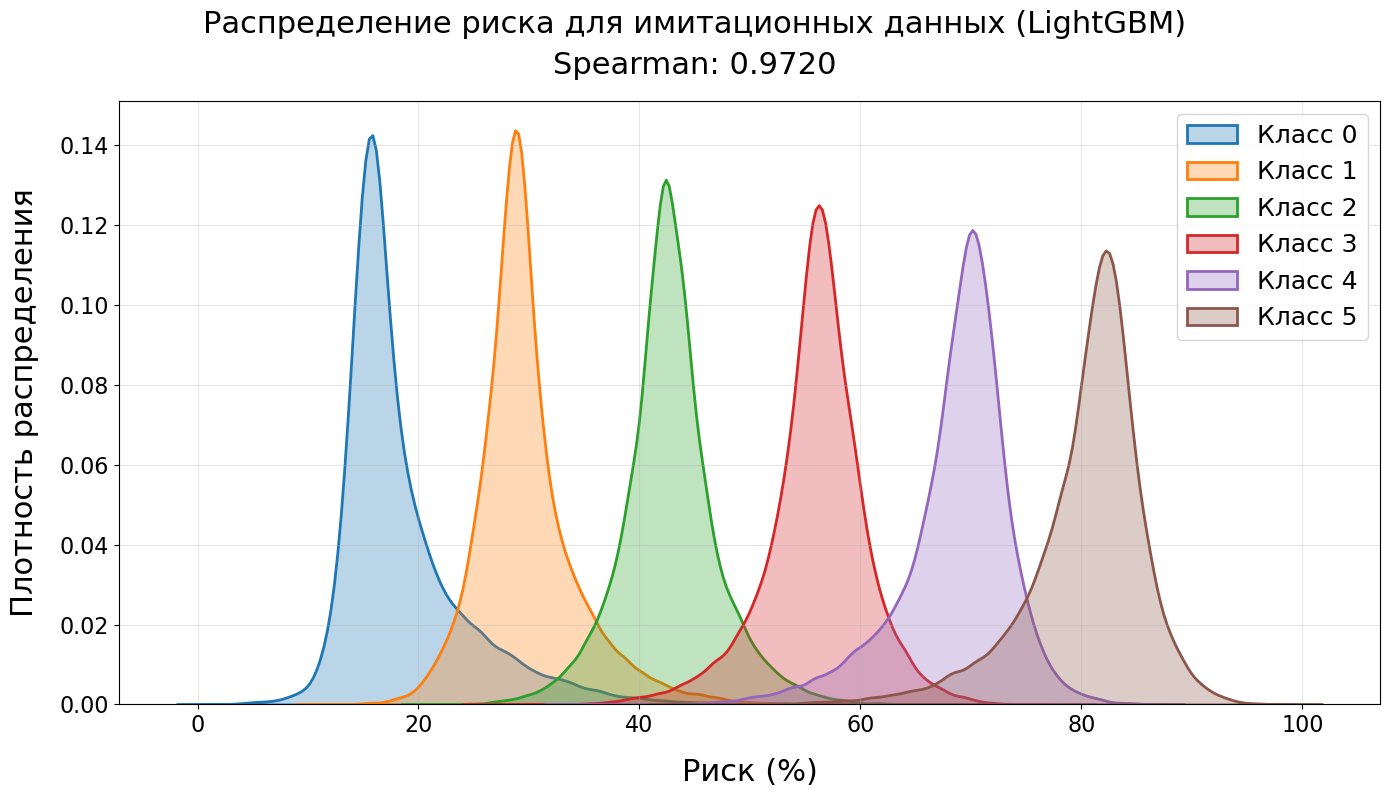

In [3]:

fig = plt.figure(figsize=(14, 8))
for new_class in range(n_classes):
    data = risk_all[y_mapped == new_class]
    old_class = inverse_mapping[new_class]
    
    sns.kdeplot(
        data,
        label=f'Класс {new_class}',
        fill=True,
        alpha=0.3,
        linewidth=2
    )
plt.xlabel("Риск (%)", fontsize=22, fontweight='medium', labelpad=15)
plt.ylabel("Плотность распределения", fontsize=22, fontweight='medium', labelpad=15)
fig.suptitle(f"Распределение риска для имитационных данных (LightGBM)\nSpearman: {spearman_corr:.4f}", fontsize=22, y=0.99, fontweight="medium", linespacing=1.5)
plt.legend(loc='upper right', fontsize=18)
plt.grid(alpha=0.3)
plt.tick_params(axis='x', labelsize=16)
plt.tick_params(axis='y', labelsize=16)
plt.tight_layout()
# plt.savefig('APPLICATIONS/risk_distribution_xgb.png', dpi=600, bbox_inches='tight')
plt.show()

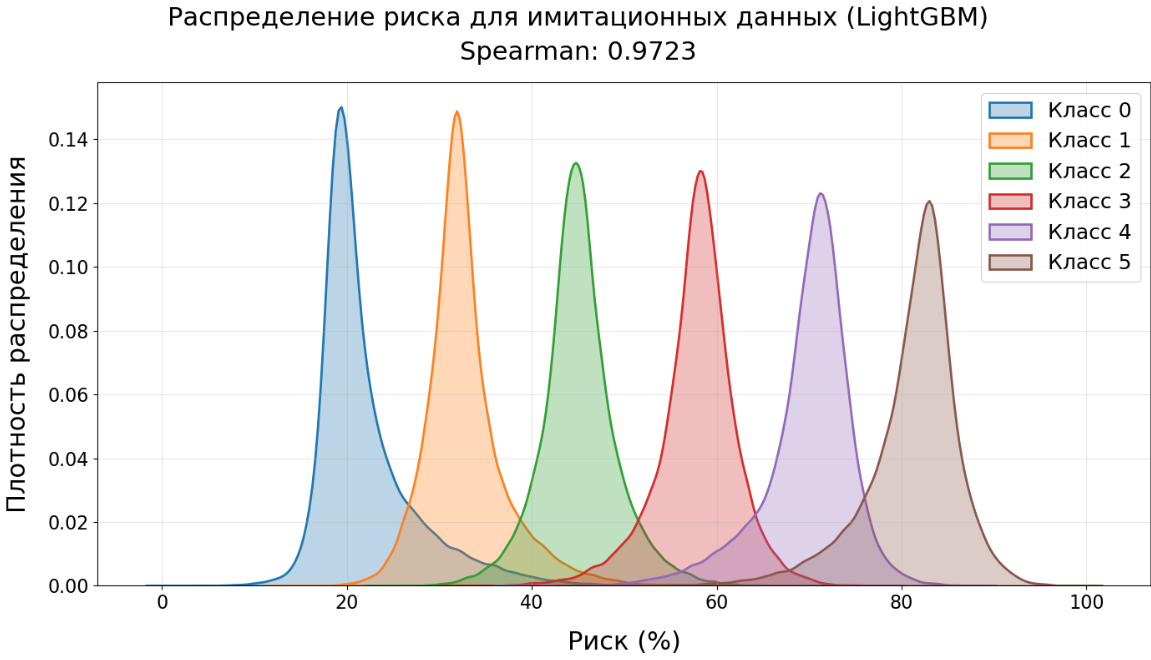

In [ ]:
import json
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

from sklearn.preprocessing import StandardScaler

from lightgbm import LGBMRegressor


# ==================== ПАРАМЕТРЫ ====================
RANDOM_STATE = 42
NOISE_STD = 0.3

# Фиксируем перестановку
fixed_perm = [0, 1, 2, 3, 4, 5]

np.random.seed(RANDOM_STATE)

# ==================== ДАННЫЕ ====================
features_df_1 = pd.read_csv("DATA/features/MATLAB_features_ws64_overlap75.csv")
features_df_2 = pd.read_csv(f"DATA/features_test_flight/MATLAB_TEST_features_ws64_overlap75.csv")
features_df = pd.concat([features_df_1, features_df_2], axis=0, ignore_index=True)

print(f"Размер первого датасета: {features_df_1.shape}")
print(f"Размер второго датасета: {features_df_2.shape}")
print(f"Размер объединенного датасета: {features_df.shape}")

X = features_df.drop(columns=["Класс"]).to_numpy(dtype=np.float32)
y_raw = features_df["Класс"].to_numpy()

class_mapping = {val: i for i, val in enumerate(sorted(np.unique(y_raw), reverse=True))}
y = np.array([class_mapping[val] for val in y_raw])
n_classes = len(np.unique(y))

# ==================== МАППИНГ ====================
mapping = {old: new for new, old in enumerate(fixed_perm)}
inverse_mapping = {v: k for k, v in mapping.items()}
y_mapped = np.array([mapping[v] for v in y])

# ==================== SCALER ====================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# =========================================================
# REGRESSION БЛОК 
# =========================================================
y_reg = y_mapped.astype(float) + np.random.normal(
    0, NOISE_STD, size=len(y_mapped)
)

reg_model = LGBMRegressor(
    n_estimators=400,
    max_depth=10,
    random_state=RANDOM_STATE,
    verbose=-1
)

reg_model.fit(X, y_reg)

reg_all = reg_model.predict(X)

r_min, r_max = reg_all.min(), reg_all.max()
reg_all_n = (reg_all - r_min) / (r_max - r_min)


# =========================================================
# РИСК (только регрессия, alpha не используется)
# =========================================================
risk_all = 100 * reg_all_n
risk_all = np.clip(risk_all, 0, 100)

# Ordinal + LReg

Spearman correlation: 0.9738
p-value: 0.0000e+00

Статистика Latent Risk по классам:

  Класс 0: средний риск = 15.70%
  Класс 1: средний риск = 27.07%
  Класс 2: средний риск = 40.61%
  Класс 3: средний риск = 54.90%
  Класс 4: средний риск = 68.10%
  Класс 5: средний риск = 81.55%

Детальная статистика:


Новый класс,Исходный класс,Среднее,Std,Медиана,25%,75%,Минимум,Максимум
0,0,15.70,5.98,13.96,11.62,18.90,0.00,44.67
1,1,27.07,4.70,26.51,24.06,29.57,8.72,53.53
2,2,40.61,4.44,40.60,37.98,43.13,23.79,63.96
3,3,54.90,4.84,55.42,52.13,57.92,31.82,72.43
4,4,68.10,5.30,68.96,65.40,71.63,41.67,86.21
5,5,81.55,5.34,82.38,79.03,84.93,53.51,100.00


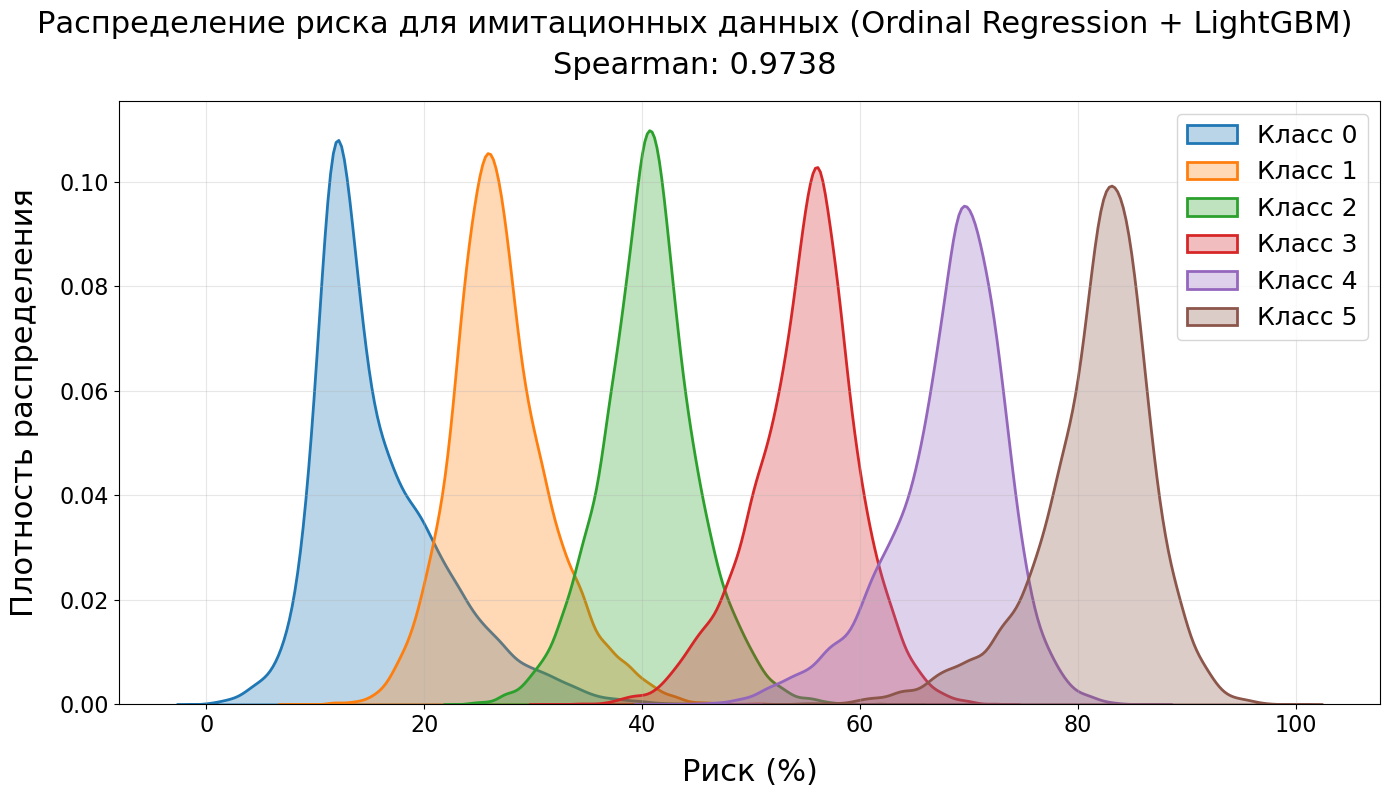

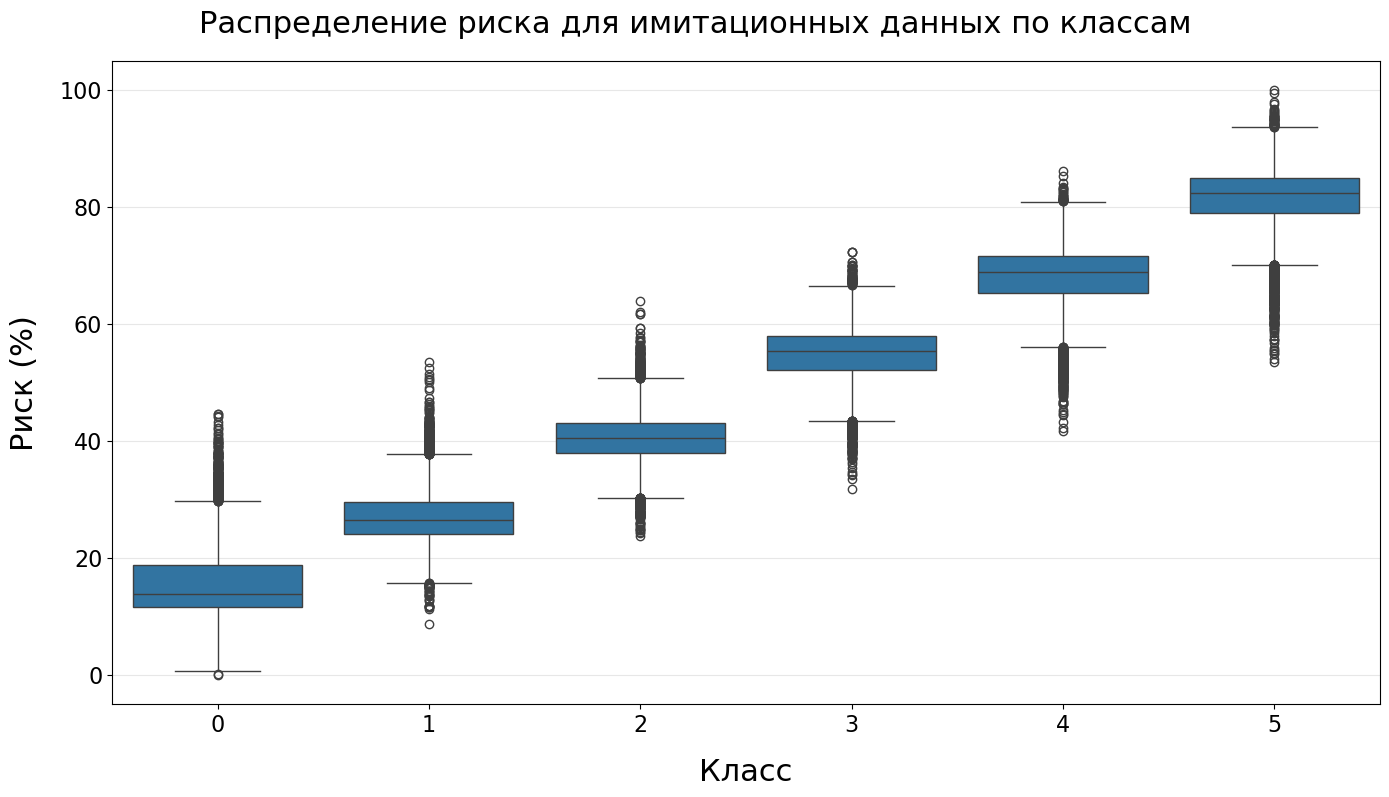

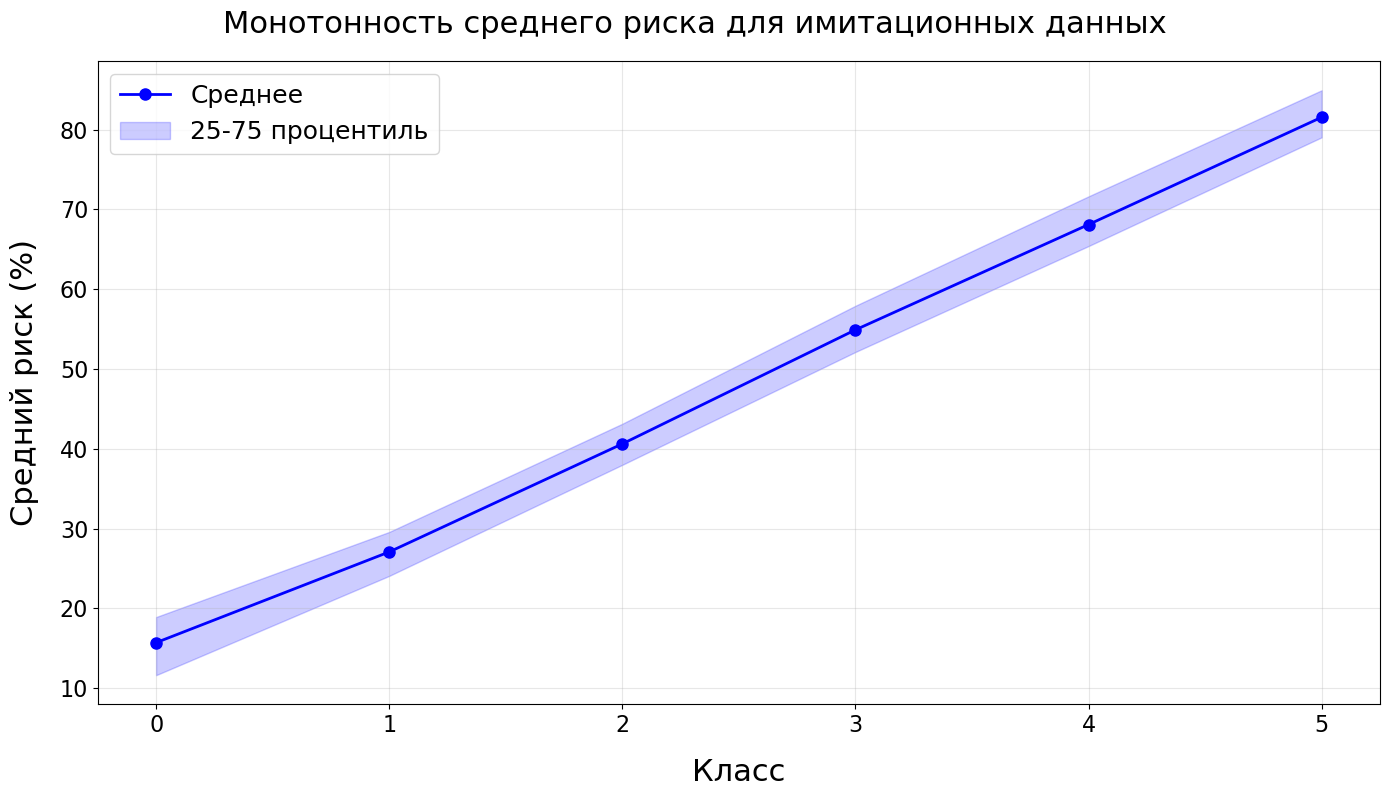

In [1]:
import json
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from lightgbm import LGBMRegressor


# ==================== ПАРАМЕТРЫ ====================
NUM_OF_FEATURES = 200
RANDOM_STATE = 42
NOISE_STD = 0.3
ALPHA = 0

# Фиксируем перестановку
fixed_perm = [0, 1, 2, 3, 4, 5]

np.random.seed(RANDOM_STATE)

# ==================== ДАННЫЕ ====================
features_df = pd.read_csv("DATA/features/MATLAB_features_ws256_overlap75.csv")

with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    selected_features = json.load(f)["optimal_features"][:NUM_OF_FEATURES]

X = features_df[selected_features].to_numpy(dtype=np.float32)
y_raw = features_df["Класс"].to_numpy()

class_mapping = {val: i for i, val in enumerate(sorted(np.unique(y_raw), reverse=True))}
y = np.array([class_mapping[val] for val in y_raw])
n_classes = len(np.unique(y))

# ==================== МАППИНГ ====================
mapping = {old: new for new, old in enumerate(fixed_perm)}
inverse_mapping = {v: k for k, v in mapping.items()}
y_mapped = np.array([mapping[v] for v in y])

# ==================== SCALER ====================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# =========================================================
# ORDINAL БЛОК 
# =========================================================
ordinal_models = []

for k in range(1, n_classes):
    y_binary = (y_mapped >= k).astype(int)

    clf = LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    )
    clf.fit(X_scaled, y_binary)
    ordinal_models.append(clf)

ordinal_all = np.mean(
    [m.decision_function(X_scaled) for m in ordinal_models],
    axis=0
)

o_min, o_max = ordinal_all.min(), ordinal_all.max()
ordinal_all_n = (ordinal_all - o_min) / (o_max - o_min)


# =========================================================
# REGRESSION БЛОК 
# =========================================================
y_reg = y_mapped.astype(float) + np.random.normal(
    0, NOISE_STD, size=len(y_mapped)
)

reg_model = LGBMRegressor(
    n_estimators=400,
    max_depth=10,
    random_state=RANDOM_STATE,
    verbose=-1
)

reg_model.fit(X, y_reg)

reg_all = reg_model.predict(X)

r_min, r_max = reg_all.min(), reg_all.max()
reg_all_n = (reg_all - r_min) / (r_max - r_min)


# =========================================================
# HYBRID 
# =========================================================
risk_all = 100 * (ALPHA * ordinal_all_n + (1 - ALPHA) * reg_all_n)
risk_all = np.clip(risk_all, 0, 100)

spearman_corr, p_value = spearmanr(risk_all, y_mapped)

print(f"Spearman correlation: {spearman_corr:.4f}")
print(f"p-value: {p_value:.4e}")

print("\nСтатистика Latent Risk по классам:\n")

stats = []

for new_class in range(n_classes):
    data = risk_all[y_mapped == new_class]
    old_class = inverse_mapping[new_class]

    mean_val = np.mean(data)

    stats.append({
        'Новый класс': new_class,
        'Исходный класс': old_class,
        'Среднее': mean_val,
        'Std': np.std(data),
        'Медиана': np.median(data),
        '25%': np.percentile(data, 25),
        '75%': np.percentile(data, 75),
        'Минимум': np.min(data),
        'Максимум': np.max(data)
    })

    print(f"  Класс {new_class}: средний риск = {mean_val:.2f}%")

stats_df = pd.DataFrame(stats)
print("\nДетальная статистика:")
display(stats_df.style.hide(axis='index').format({
    'Среднее': '{:.2f}',
    'Std': '{:.2f}',
    'Медиана': '{:.2f}',
    '25%': '{:.2f}',
    '75%': '{:.2f}',
    'Минимум': '{:.2f}',
    'Максимум': '{:.2f}'
}))

# ==================== ГРАФИК 1: KDE распределение ====================

fig = plt.figure(figsize=(14, 8))
for new_class in range(n_classes):
    data = risk_all[y_mapped == new_class]
    old_class = inverse_mapping[new_class]
    
    sns.kdeplot(
        data,
        label=f'Класс {new_class}',
        fill=True,
        alpha=0.3,
        linewidth=2
    )
plt.xlabel("Риск (%)", fontsize=22, fontweight='medium', labelpad=15)
plt.ylabel("Плотность распределения", fontsize=22, fontweight='medium', labelpad=15)
fig.suptitle(f"Распределение риска для имитационных данных (Ordinal Regression + LightGBM)\nSpearman: {spearman_corr:.4f}", fontsize=22, y=0.99, fontweight="medium", linespacing=1.5)
plt.legend(loc='upper right', fontsize=18)
plt.grid(alpha=0.3)
plt.tick_params(axis='x', labelsize=16)
plt.tick_params(axis='y', labelsize=16)
plt.tight_layout()
# plt.savefig('APPLICATIONS/risk_distribution_xgb.png', dpi=600, bbox_inches='tight')
plt.show()

# ==================== ГРАФИК 2: Boxplot ====================

fig = plt.figure(figsize=(14, 8))

data_for_box = []
labels_for_box = []

for new_class in range(n_classes):
    data_for_box.extend(risk_all[y_mapped == new_class])
    old_class = inverse_mapping[new_class]
    labels_for_box.extend(
        [f'{new_class}'] * sum(y_mapped == new_class)
    )

df_box = pd.DataFrame({'Класс': labels_for_box, 'Риск': data_for_box})

sns.boxplot(data=df_box, x='Класс', y='Риск')

fig.suptitle('Распределение риска для имитационных данных по классам', fontsize=22, y=0.99, fontweight="medium")
plt.ylabel('Риск (%)', fontsize=22, fontweight='medium', labelpad=15)
plt.xlabel('Класс', fontsize=22, fontweight='medium', labelpad=15)
plt.grid(alpha=0.3, axis='y')
plt.tick_params(axis='x', labelsize=16)
plt.tick_params(axis='y', labelsize=16)
plt.tight_layout()
# plt.savefig('APPLICATIONS/risk_boxplot_xgb.png', dpi=600, bbox_inches='tight')
plt.show()

# ==================== ГРАФИК 3: Монотонность среднего риска ====================

fig = plt.figure(figsize=(14, 8))

means = [np.mean(risk_all[y_mapped == c]) for c in range(n_classes)]
new_classes = range(n_classes)
old_labels = [f"{c}\n({inverse_mapping[c]})" for c in new_classes]

plt.plot(new_classes, means, 'o-', linewidth=2, markersize=8, color='blue', label='Среднее')

# Добавляем доверительный интервал (25-75 процентили)
plt.fill_between(
    new_classes,
    [np.percentile(risk_all[y_mapped == c], 25) for c in new_classes],
    [np.percentile(risk_all[y_mapped == c], 75) for c in new_classes],
    alpha=0.2,
    color='blue',
    label='25-75 процентиль'
)

# plt.xticks(new_classes, old_labels)
plt.xlabel('Класс', fontsize=22, fontweight='medium', labelpad=15)
plt.ylabel('Средний риск (%)', fontsize=22, fontweight='medium', labelpad=15)
fig.suptitle('Монотонность среднего риска для имитационных данных', fontsize=22, y=0.99, fontweight="medium")
plt.grid(alpha=0.3)
plt.legend(loc='upper left', fontsize=18)
plt.tick_params(axis='x', labelsize=16)
plt.tick_params(axis='y', labelsize=16)
plt.tight_layout()
# plt.savefig('APPLICATIONS/risk_monotonicity_xgb.png', dpi=600, bbox_inches='tight')
plt.show()

# ========= ГРАФИК 4: UNCERTAINTY (разброс внутри класса) =========

# fig = plt.figure(figsize=(10, 6))

# uncertainty = np.abs(ordinal_test_n - reg_test_n)

# scatter = plt.scatter(
#     best_risk,
#     uncertainty,
#     c=best_y_test_m,
#     cmap='viridis',
#     alpha=0.5,
#     s=10
# )

# plt.colorbar(scatter, label='Class')

# plt.xlabel("Risk (%)", fontsize=12)
# plt.ylabel("Uncertainty |Ordinal - Reg|", fontsize=12)
# fig.suptitle("Uncertainty vs Risk", fontsize=14, y=0.99)


# plt.axhline(y=np.mean(uncertainty), 
#             linestyle='--', 
#             alpha=0.7, 
#             linewidth=1,
#             label='Mean uncertainty', 
#             color="black")

# plt.legend()
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.savefig('APPLICATIONS/4.png', dpi=1000, bbox_inches='tight')
# plt.show()

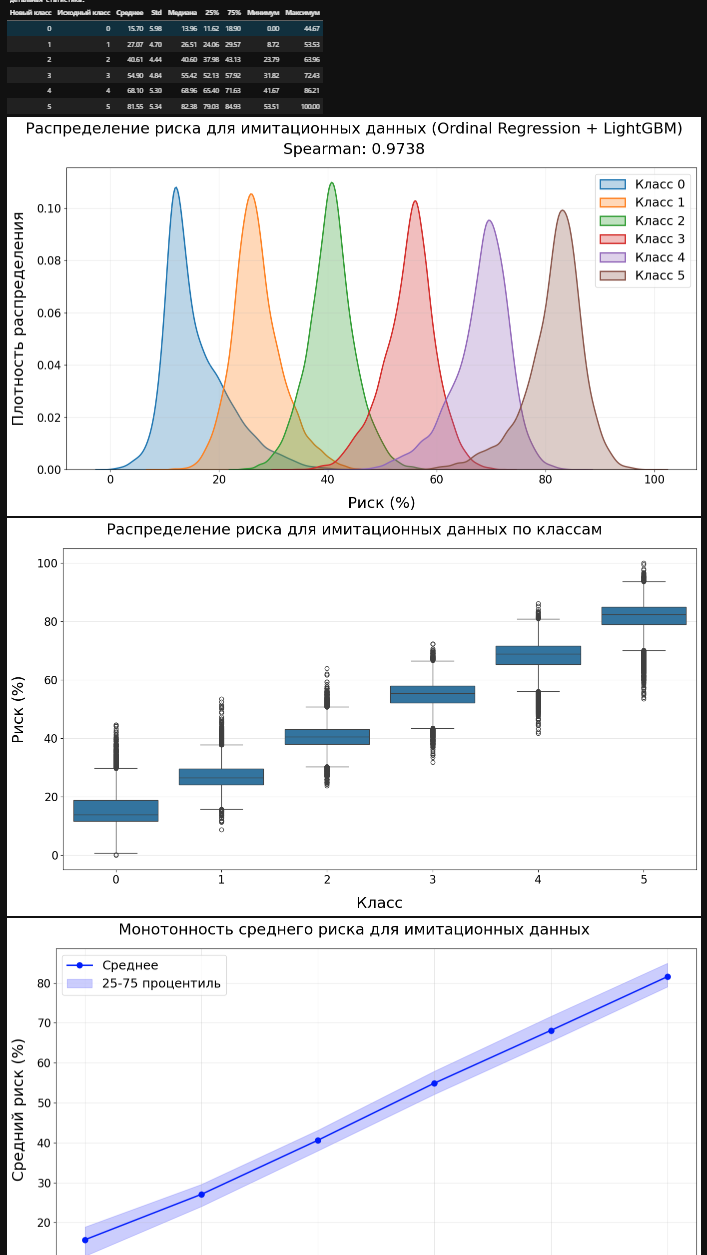

Spearman correlation: 0.9738
p-value: 0.0000e+00

Статистика Latent Risk по классам:

  Класс 0: средний риск = 15.70%
  Класс 1: средний риск = 27.07%
  Класс 2: средний риск = 40.61%
  Класс 3: средний риск = 54.90%
  Класс 4: средний риск = 68.10%
  Класс 5: средний риск = 81.55%

Детальная статистика:


Новый класс,Исходный класс,Среднее,Std,Медиана,25%,75%,Минимум,Максимум
0,0,15.70,5.98,13.96,11.62,18.90,0.00,44.67
1,1,27.07,4.70,26.51,24.06,29.57,8.72,53.53
2,2,40.61,4.44,40.60,37.98,43.13,23.79,63.96
3,3,54.90,4.84,55.42,52.13,57.92,31.82,72.43
4,4,68.10,5.30,68.96,65.40,71.63,41.67,86.21
5,5,81.55,5.34,82.38,79.03,84.93,53.51,100.00


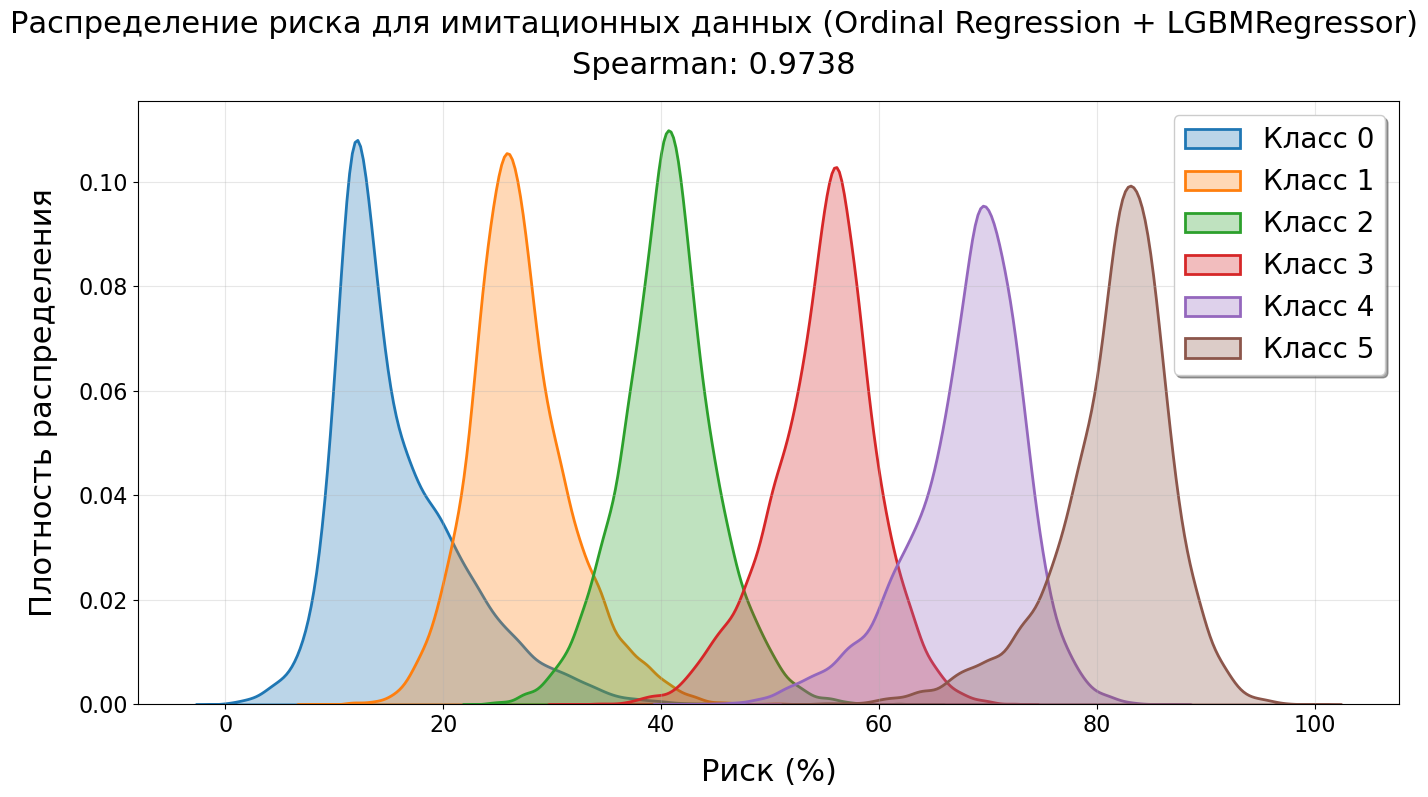

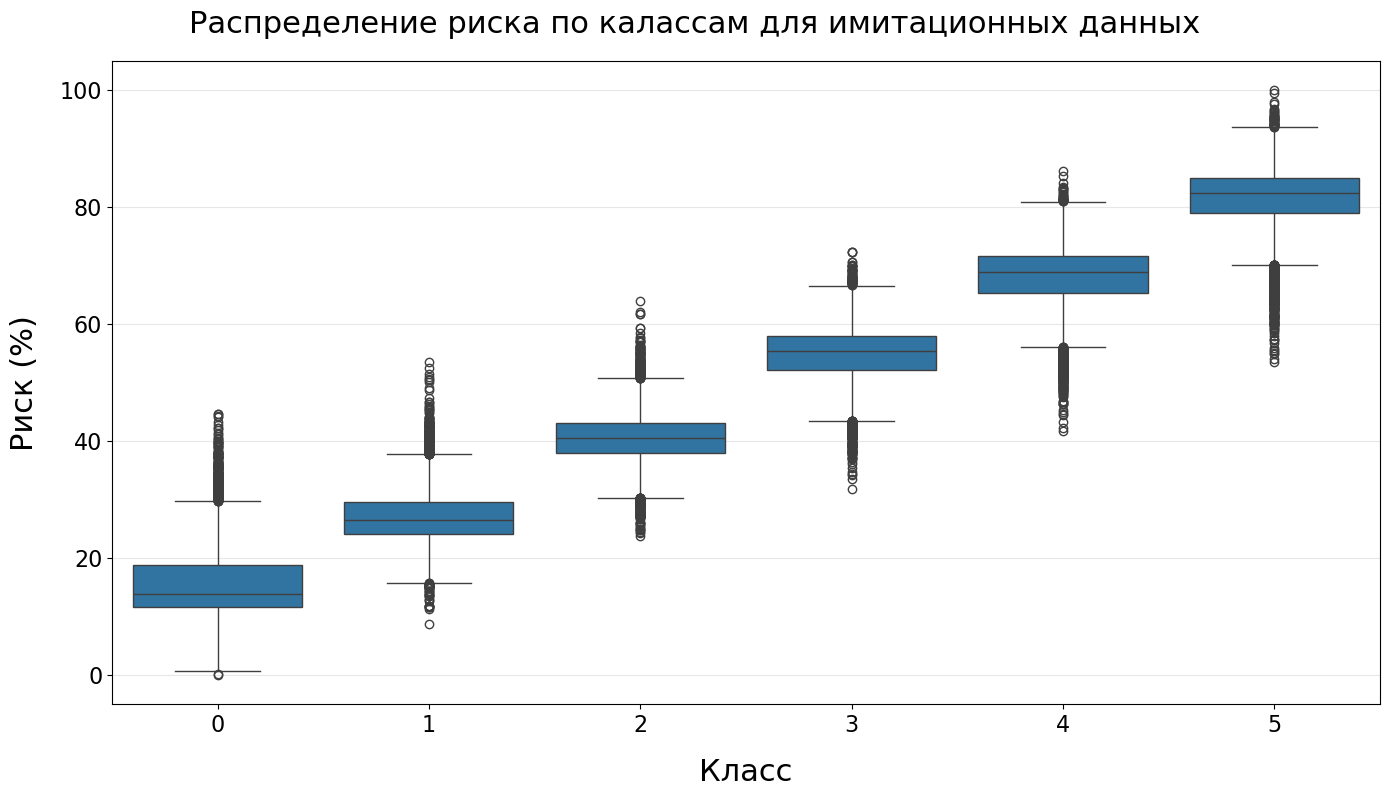

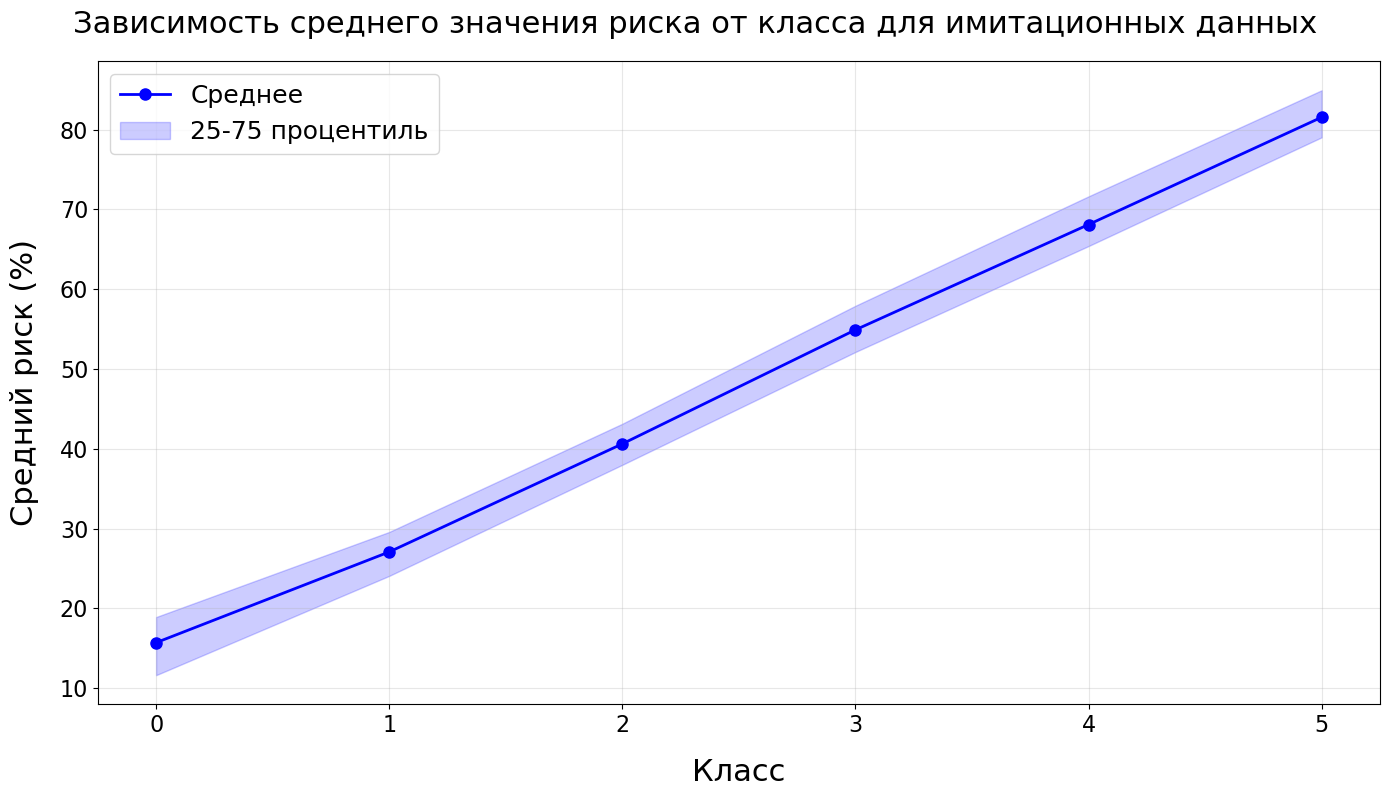

In [2]:
ALPHA = 0

# =========================================================
# HYBRID 
# =========================================================
risk_all = 100 * (ALPHA * ordinal_all_n + (1 - ALPHA) * reg_all_n)
risk_all = np.clip(risk_all, 0, 100)

spearman_corr, p_value = spearmanr(risk_all, y_mapped)

print(f"Spearman correlation: {spearman_corr:.4f}")
print(f"p-value: {p_value:.4e}")

print("\nСтатистика Latent Risk по классам:\n")

stats = []

for new_class in range(n_classes):
    data = risk_all[y_mapped == new_class]
    old_class = inverse_mapping[new_class]

    mean_val = np.mean(data)

    stats.append({
        'Новый класс': new_class,
        'Исходный класс': old_class,
        'Среднее': mean_val,
        'Std': np.std(data),
        'Медиана': np.median(data),
        '25%': np.percentile(data, 25),
        '75%': np.percentile(data, 75),
        'Минимум': np.min(data),
        'Максимум': np.max(data)
    })

    print(f"  Класс {new_class}: средний риск = {mean_val:.2f}%")

stats_df = pd.DataFrame(stats)
print("\nДетальная статистика:")
display(stats_df.style.hide(axis='index').format({
    'Среднее': '{:.2f}',
    'Std': '{:.2f}',
    'Медиана': '{:.2f}',
    '25%': '{:.2f}',
    '75%': '{:.2f}',
    'Минимум': '{:.2f}',
    'Максимум': '{:.2f}'
}))

# ==================== ГРАФИК 1: KDE распределение ====================

fig = plt.figure(figsize=(14, 8))
for new_class in range(n_classes):
    data = risk_all[y_mapped == new_class]
    old_class = inverse_mapping[new_class]
    
    sns.kdeplot(
        data,
        label=f'Класс {new_class}',
        fill=True,
        alpha=0.3,
        linewidth=2
    )
plt.xlabel("Риск (%)", fontsize=22, fontweight='medium', labelpad=15)
plt.ylabel("Плотность распределения", fontsize=22, fontweight='medium', labelpad=15)
fig.suptitle(f"Распределение риска для имитационных данных (Ordinal Regression + LGBMRegressor)\nSpearman: {spearman_corr:.4f}", fontsize=22, y=0.99, fontweight="medium", linespacing=1.5)
plt.legend(loc='upper right', fontsize=20, frameon=True, shadow=True)
plt.grid(alpha=0.3)
plt.tick_params(axis='x', labelsize=16)
plt.tick_params(axis='y', labelsize=16)
plt.tight_layout()
plt.savefig('APPLICATIONS/risk_distribution_xgb.png', dpi=600, bbox_inches='tight')
plt.show()

# ==================== ГРАФИК 2: Boxplot ====================

fig = plt.figure(figsize=(14, 8))

data_for_box = []
labels_for_box = []

for new_class in range(n_classes):
    data_for_box.extend(risk_all[y_mapped == new_class])
    old_class = inverse_mapping[new_class]
    labels_for_box.extend(
        [f'{new_class}'] * sum(y_mapped == new_class)
    )

df_box = pd.DataFrame({'Класс': labels_for_box, 'Риск': data_for_box})

sns.boxplot(data=df_box, x='Класс', y='Риск')

fig.suptitle('Распределение риска по калассам для имитационных данных', fontsize=22, y=0.99, fontweight="medium")
plt.ylabel('Риск (%)', fontsize=22, fontweight='medium', labelpad=15)
plt.xlabel('Класс', fontsize=22, fontweight='medium', labelpad=15)
plt.grid(alpha=0.3, axis='y')
plt.tick_params(axis='x', labelsize=16)
plt.tick_params(axis='y', labelsize=16)
plt.tight_layout()
# plt.savefig('APPLICATIONS/risk_boxplot_xgb.png', dpi=600, bbox_inches='tight')
plt.show()

# ==================== ГРАФИК 3: Монотонность среднего риска ====================

fig = plt.figure(figsize=(14, 8))

means = [np.mean(risk_all[y_mapped == c]) for c in range(n_classes)]
new_classes = range(n_classes)
old_labels = [f"{c}\n({inverse_mapping[c]})" for c in new_classes]

plt.plot(new_classes, means, 'o-', linewidth=2, markersize=8, color='blue', label='Среднее')

# Добавляем доверительный интервал (25-75 процентили)
plt.fill_between(
    new_classes,
    [np.percentile(risk_all[y_mapped == c], 25) for c in new_classes],
    [np.percentile(risk_all[y_mapped == c], 75) for c in new_classes],
    alpha=0.2,
    color='blue',
    label='25-75 процентиль'
)

# plt.xticks(new_classes, old_labels)
plt.xlabel('Класс', fontsize=22, fontweight='medium', labelpad=15)
plt.ylabel('Средний риск (%)', fontsize=22, fontweight='medium', labelpad=15)
fig.suptitle('Зависимость среднего значения риска от класса для имитационных данных', fontsize=22, y=0.99, fontweight="medium")
plt.grid(alpha=0.3)
plt.legend(loc='upper left', fontsize=18)
plt.tick_params(axis='x', labelsize=16)
plt.tick_params(axis='y', labelsize=16)
plt.tight_layout()
# plt.savefig('APPLICATIONS/risk_monotonicity_xgb.png', dpi=600, bbox_inches='tight')
plt.show()

# ========= ГРАФИК 4: UNCERTAINTY (разброс внутри класса) =========

# fig = plt.figure(figsize=(10, 6))

# uncertainty = np.abs(ordinal_test_n - reg_test_n)

# scatter = plt.scatter(
#     best_risk,
#     uncertainty,
#     c=best_y_test_m,
#     cmap='viridis',
#     alpha=0.5,
#     s=10
# )

# plt.colorbar(scatter, label='Class')

# plt.xlabel("Risk (%)", fontsize=12)
# plt.ylabel("Uncertainty |Ordinal - Reg|", fontsize=12)
# fig.suptitle("Uncertainty vs Risk", fontsize=14, y=0.99)


# plt.axhline(y=np.mean(uncertainty), 
#             linestyle='--', 
#             alpha=0.7, 
#             linewidth=1,
#             label='Mean uncertainty', 
#             color="black")

# plt.legend()
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.savefig('APPLICATIONS/4.png', dpi=1000, bbox_inches='tight')
# plt.show()

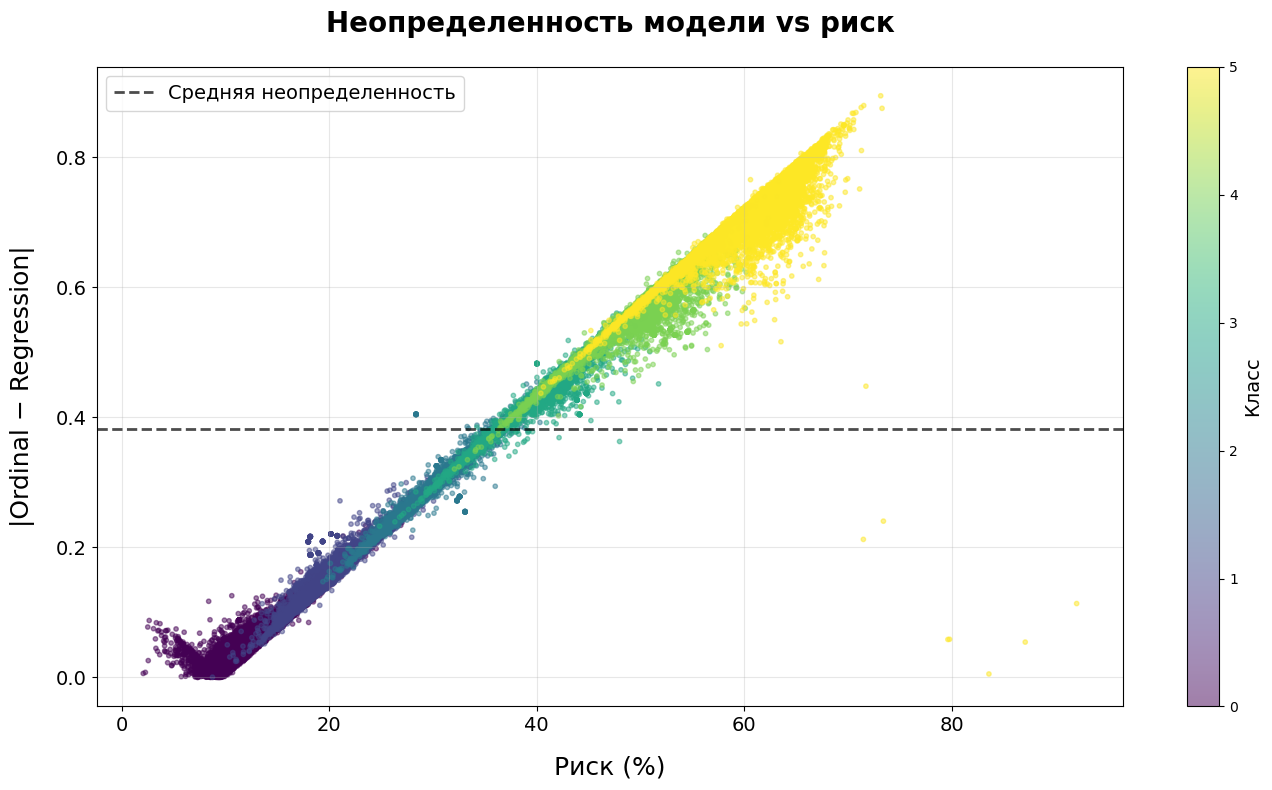

In [21]:
# ========= ГРАФИК 4: UNCERTAINTY =========

plt.figure(figsize=(14, 8))

# Разброс между моделями
uncertainty = np.abs(ordinal_all_n - reg_all_n)

scatter = plt.scatter(
    risk_all,
    uncertainty,
    c=y_mapped,
    cmap='viridis',
    alpha=0.5,
    s=10
)

cbar = plt.colorbar(scatter)
cbar.set_label('Класс', fontsize=14)

plt.xlabel("Риск (%)", fontsize=18, fontweight='medium', labelpad=15)
plt.ylabel("|Ordinal − Regression|", fontsize=18, fontweight='medium', labelpad=15)
plt.title("Неопределенность модели vs риск", fontsize=20, pad=25, fontweight="demibold")

# Средний уровень неопределенности
plt.axhline(
    y=np.mean(uncertainty),
    linestyle='--',
    alpha=0.7,
    linewidth=2,
    color="black",
    label='Средняя неопределенность'
)

plt.legend(fontsize=14)
plt.grid(alpha=0.3)
plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)

plt.tight_layout()
# plt.savefig('APPLICATIONS/risk_uncertainty.png', dpi=600, bbox_inches='tight')
plt.show()

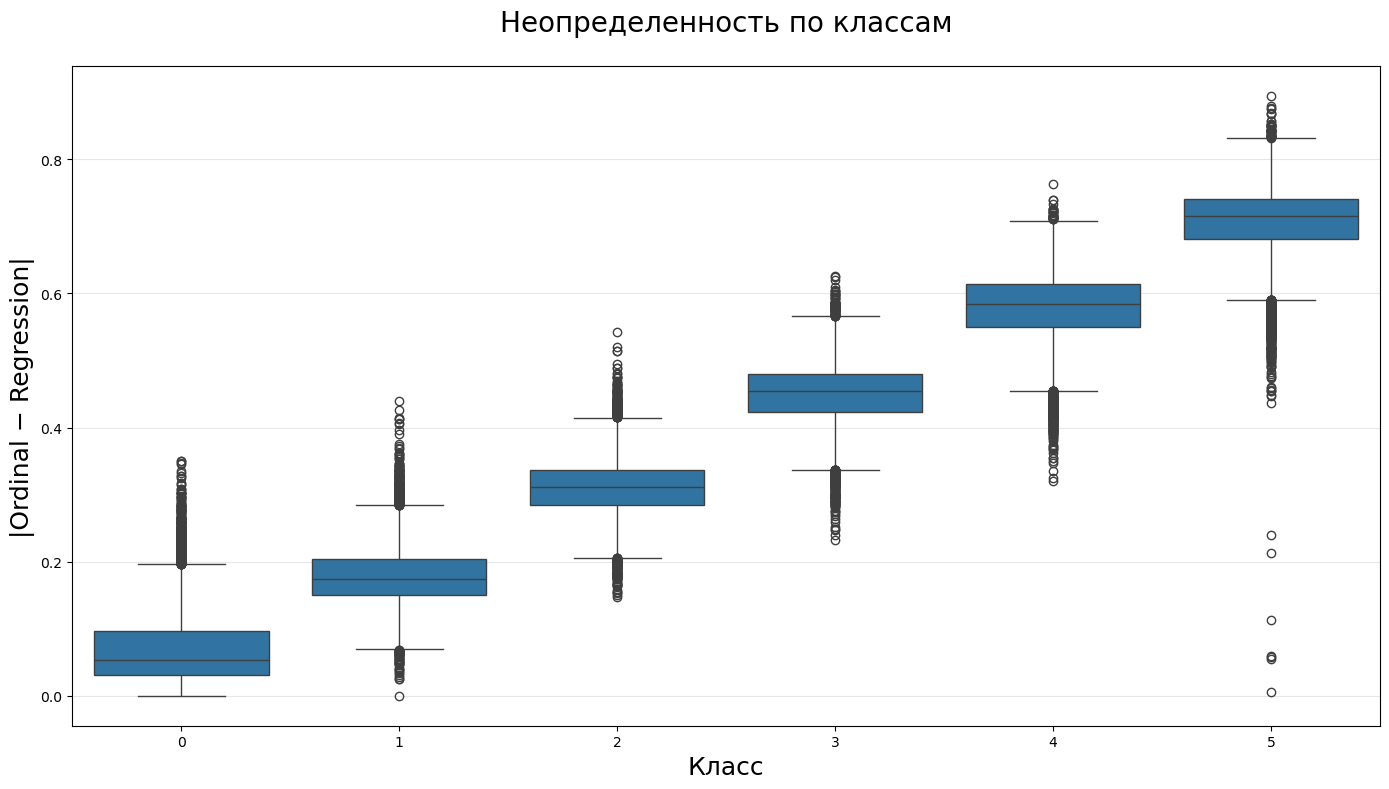

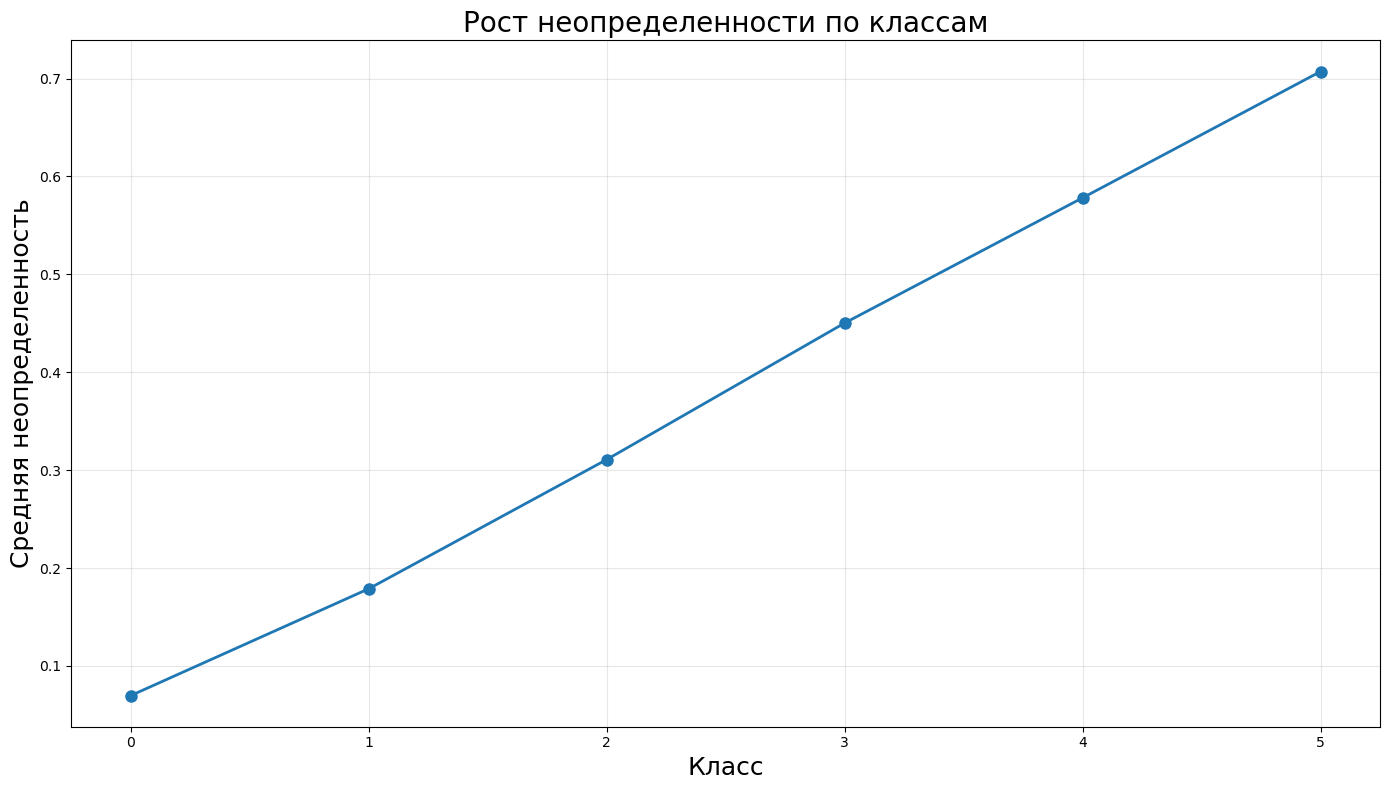

In [19]:
plt.figure(figsize=(14, 8))

unc_means = [np.mean(uncertainty[y_mapped == c]) for c in range(n_classes)]

plt.plot(range(n_classes), unc_means, 'o-', linewidth=2, markersize=8)

plt.xlabel('Класс', fontsize=18)
plt.ylabel('Средняя неопределенность', fontsize=18)
plt.title('Рост неопределенности по классам', fontsize=20)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

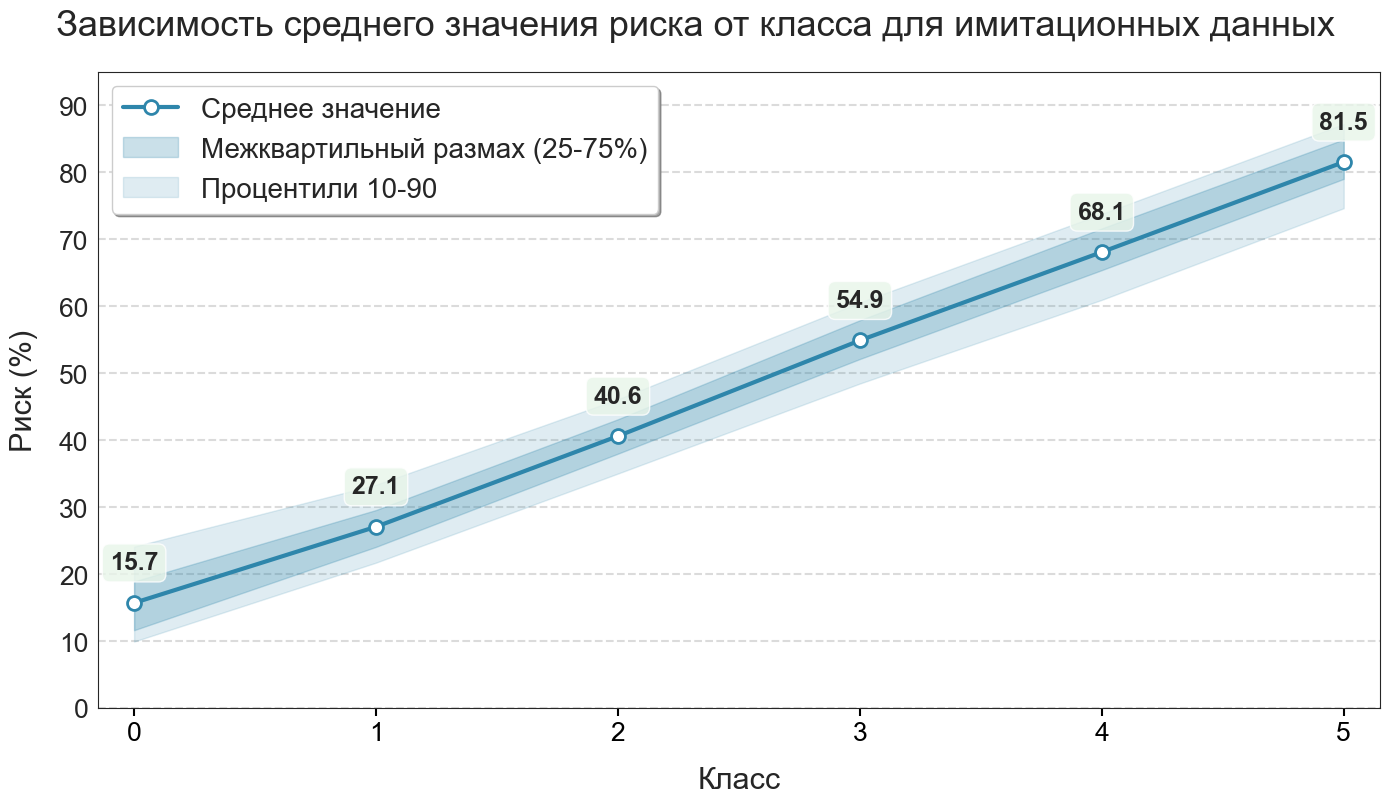

In [11]:
# ==================== ГРАФИК 3: Монотонность среднего риска (улучшенный) ====================
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['axes.titlecolor'] = 'black'

sns.set_style("white")  # Включает насечки и белый фон
sns.set_palette("husl")




new_classes = range(n_classes)
old_labels = [f"{c}\n({inverse_mapping[c]})" for c in new_classes]

data_for_box = []
labels_for_box = []

for new_class in range(n_classes):
    data_for_box.extend(risk_all[y_mapped == new_class])
    old_class = inverse_mapping[new_class]
    labels_for_box.extend([f'{new_class}'] * sum(y_mapped == new_class))

    
fig = plt.figure(figsize=(14, 8))

plt.tick_params(
    axis='x',        # Обе оси
    which='both',       # Основные и второстепенные
    direction='out',    # Насечки наружу
    length=6,           # Длина насечки
    width=1.5,          # Толщина насечки
    colors='black',     # Цвет насечек
    labelsize=18,       # Размер подписей
    bottom=True,        # Нижние насечки
    left=True,          # Левые насечки
    top=False,          # Без верхних
    right=False         # Без правых
)

# Расчет статистик
means = [np.mean(risk_all[y_mapped == c]) for c in range(n_classes)]
medians = [np.median(risk_all[y_mapped == c]) for c in range(n_classes)]
q25 = [np.percentile(risk_all[y_mapped == c], 25) for c in range(n_classes)]
q75 = [np.percentile(risk_all[y_mapped == c], 75) for c in range(n_classes)]
q10 = [np.percentile(risk_all[y_mapped == c], 10) for c in range(n_classes)]
q90 = [np.percentile(risk_all[y_mapped == c], 90) for c in range(n_classes)]

# Основная линия с маркерами
plt.plot(new_classes, means, 'o-', linewidth=3, markersize=10, 
         color='#2E86AB', label='Среднее значение', markerfacecolor='white', 
         markeredgewidth=2, markeredgecolor='#2E86AB')

# Закрашенная область межквартильного размаха (25-75 процентили)
plt.fill_between(new_classes, q25, q75, alpha=0.25, color='#2E86AB', 
                  label='Межквартильный размах (25-75%)')

# Дополнительная область для 10-90 процентилей (более светлая)
plt.fill_between(new_classes, q10, q90, alpha=0.15, color='#2E86AB', 
                  label='Процентили 10-90')

# Добавляем аннотации с значениями
for i, (mean_val, median_val) in enumerate(zip(means, medians)):
    plt.annotate(f'{mean_val:.1f}', 
                 xy=(i, mean_val), 
                 xytext=(i, mean_val + 5),
                 ha='center', 
                 fontsize=18, 
                 fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#E8F5E9', alpha=0.8))


# Улучшенные метки и заголовок
plt.xlabel('Класс', fontsize=22, fontweight='medium', labelpad=15)
plt.ylabel('Риск (%)', fontsize=22, fontweight='medium', labelpad=15)

fig.suptitle('Зависимость среднего значения риска от класса для имитационных данных', 
             fontsize=26, y=1, fontweight='medium')



# Легенда с улучшенным стилем
plt.legend(loc='upper left', fontsize=20, frameon=True, shadow=True)

plt.tick_params(axis='x', labelsize=19)
plt.tick_params(axis='y', labelsize=19)

plt.ylim(0, 95)
plt.yticks(np.arange(0, 91, 10))
plt.xlim(-0.15, 5.15)


# Улучшенная сетка

plt.grid(alpha=0.7, axis='y', linestyle='--', linewidth=1.5)  # Оставляем только горизонтальные

plt.tight_layout()
plt.savefig('risk_monotonicity_improved.png', dpi=600, bbox_inches='tight')
plt.show()

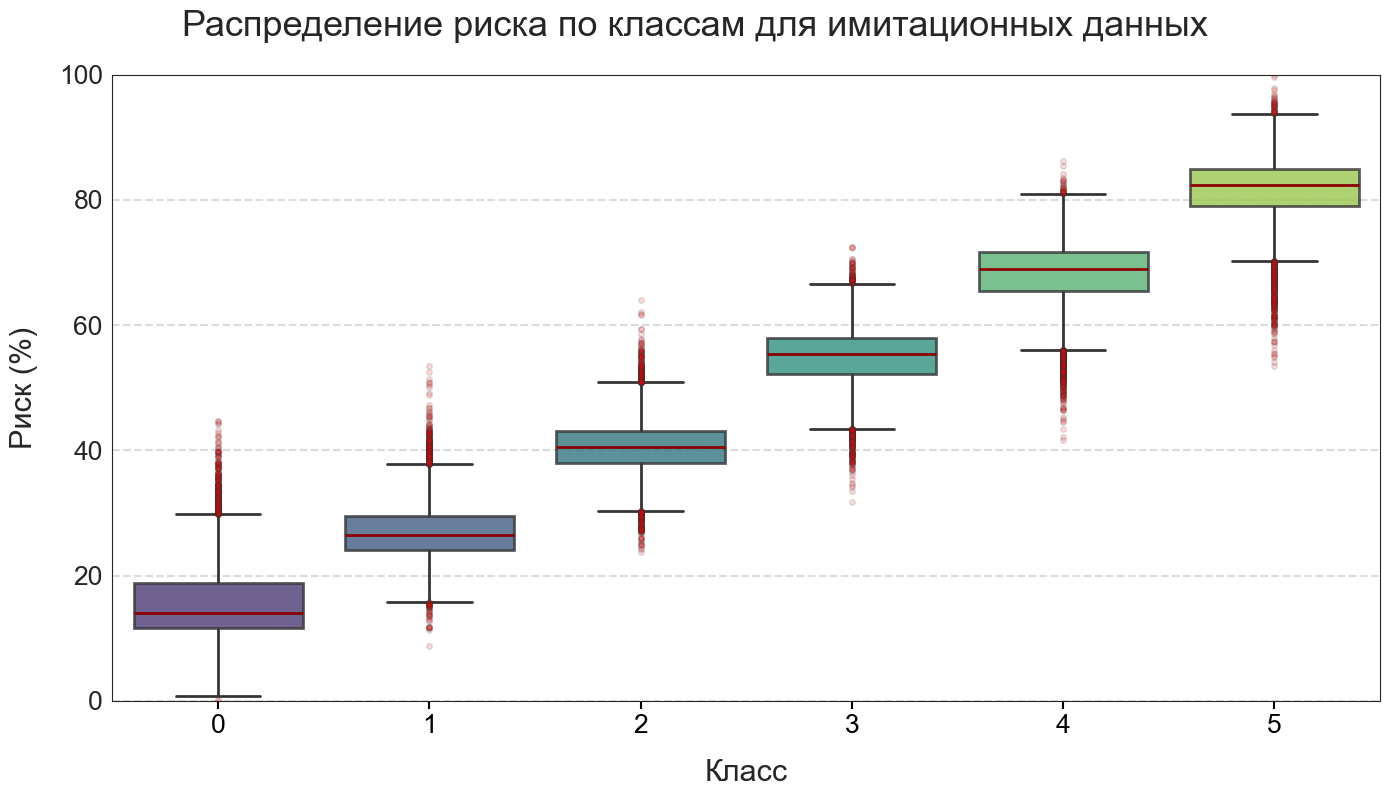

In [12]:
# ==================== ГРАФИК 2: Boxplot (улучшенный) ====================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Установка черного цвета для всего текста
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['axes.titlecolor'] = 'black'

# Настройка стиля seaborn для более современного вида
sns.set_style("white")
# sns.set_palette("husl")

# sns.set_style("darkgrid")
# sns.set_palette("deep")

fig = plt.figure(figsize=(14, 8))

plt.tick_params(
    axis='x',        # Обе оси
    which='both',       # Основные и второстепенные
    direction='out',    # Насечки наружу
    length=6,           # Длина насечки
    width=1.5,          # Толщина насечки
    colors='black',     # Цвет насечек
    labelsize=18,       # Размер подписей
    bottom=True,        # Нижние насечки
    left=True,          # Левые насечки
    top=False,          # Без верхних
    right=False         # Без правых
)

new_classes = range(n_classes)
old_labels = [f"{c}\n({inverse_mapping[c]})" for c in new_classes]

data_for_box = []
labels_for_box = []

for new_class in range(n_classes):
    data_for_box.extend(risk_all[y_mapped == new_class])
    old_class = inverse_mapping[new_class]
    labels_for_box.extend([f'{new_class}'] * sum(y_mapped == new_class))

df_box = pd.DataFrame({'Class': labels_for_box, 'Risk': data_for_box})

# Улучшенный boxplot с дополнительными элементами
boxplot = sns.boxplot(
    data=df_box, 
    x='Class', 
    y='Risk',
    palette='viridis',  # Более красивая цветовая схема
    linewidth=2,
    flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 4, 'alpha': 0.15},
    boxprops={'alpha': 0.8},
    whiskerprops={'linewidth': 2},
    capprops={'linewidth': 2},
    medianprops={'linewidth': 2, 'color': 'darkred'}
)


# Улучшенные метки и заголовок
fig.suptitle('Распределение риска по классам для имитационных данных', fontsize=26, y=0.99, fontweight="medium")

plt.ylabel('Риск (%)', fontsize=22, fontweight='medium', labelpad=15)
plt.xlabel('Класс', fontsize=22, fontweight='medium', labelpad=15)
plt.grid(alpha=0.7, axis='y', linestyle='--', linewidth=1.5)
plt.tick_params(axis='x', labelsize=19)
plt.tick_params(axis='y', labelsize=19)
plt.ylim(0, 100)
plt.yticks(np.arange(0, 101, 20))


plt.tight_layout()
plt.savefig('risk_boxplot_improved.png', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
ALPHA = 0
# =========================================================
# HYBRID 
# =========================================================
risk_all = 100 * (ALPHA * ordinal_all_n + (1 - ALPHA) * reg_all_n)
risk_all = np.clip(risk_all, 0, 100)


# =========================================================
# МЕТРИКИ
# =========================================================
spearman_corr, p_value = spearmanr(risk_all, y_mapped)

print(f"Spearman correlation: {spearman_corr:.4f}")
print(f"p-value: {p_value:.4e}")

inverse_mapping = {v: k for k, v in mapping.items()}
best_perm_list = [inverse_mapping[i] for i in range(n_classes)]
print("Используемая перестановка:", best_perm_list)

print("\nСтатистика Latent Risk по классам:\n")

stats = []

for new_class in range(n_classes):
    data = risk_all[y_mapped == new_class]
    old_class = inverse_mapping[new_class]

    mean_val = np.mean(data)

    stats.append({
        'Новый класс': new_class,
        'Исходный класс': old_class,
        'Среднее': mean_val,
        'Std': np.std(data),
        'Медиана': np.median(data),
        '25%': np.percentile(data, 25),
        '75%': np.percentile(data, 75),
        'Минимум': np.min(data),
        'Максимум': np.max(data)
    })

    print(f"  Новый класс {new_class} (исх.{old_class}): средний риск = {mean_val:.2f}%")

stats_df = pd.DataFrame(stats)
print("\nДетальная статистика:")
display(stats_df.style.hide(axis='index').format({
    'Среднее': '{:.2f}',
    'Std': '{:.2f}',
    'Медиана': '{:.2f}',
    '25%': '{:.2f}',
    '75%': '{:.2f}',
    'Минимум': '{:.2f}',
    'Максимум': '{:.2f}'
}))

spearman_corr, p_value = spearmanr(risk_all, y_mapped)

# ==================== ГРАФИК 1: KDE распределение ====================
plt.figure(figsize=(12, 6))

for new_class in range(n_classes):
    data = risk_all[y_mapped == new_class]
    old_class = inverse_mapping[new_class]
    
    sns.kdeplot(
        data,
        label=f'New {new_class} (old {old_class})',
        fill=True,
        alpha=0.3,
        linewidth=2
    )
plt.xlabel("Risk (%)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title(f"Распределение риск для имитационных данных (XGBoost ordinal)\nSpearman: {spearman_corr:.4f}", fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('APPLICATIONS/risk_distribution_xgb.png', dpi=400, bbox_inches='tight')
plt.show()

# ==================== ГРАФИК 2: Boxplot ====================
plt.figure(figsize=(12, 6))

data_for_box = []
labels_for_box = []

for new_class in range(n_classes):
    data_for_box.extend(risk_all[y_mapped == new_class])
    old_class = inverse_mapping[new_class]
    labels_for_box.extend(
        [f'New {new_class}\n(old {old_class})'] * sum(y_mapped == new_class)
    )

df_box = pd.DataFrame({'Class': labels_for_box, 'Risk': data_for_box})

sns.boxplot(data=df_box, x='Class', y='Risk')

plt.title('Распределение риска для имитационных данных по классам (boxplot)', fontsize=14)
plt.ylabel('Risk (%)', fontsize=12)
plt.xlabel('Класс', fontsize=12)
plt.grid(alpha=0.3, axis='y')

plt.tight_layout()
# plt.savefig('APPLICATIONS/risk_boxplot_xgb.png', dpi=400, bbox_inches='tight')
plt.show()

# ==================== ГРАФИК 3: Монотонность среднего риска ====================
plt.figure(figsize=(12, 6))

means = [np.mean(risk_all[y_mapped == c]) for c in range(n_classes)]
new_classes = range(n_classes)
old_labels = [f"{c}\n({inverse_mapping[c]})" for c in new_classes]

plt.plot(new_classes, means, 'o-', linewidth=2, markersize=8, color='blue', label='Среднее')

# Добавляем доверительный интервал (25-75 процентили)
plt.fill_between(
    new_classes,
    [np.percentile(risk_all[y_mapped == c], 25) for c in new_classes],
    [np.percentile(risk_all[y_mapped == c], 75) for c in new_classes],
    alpha=0.2,
    color='blue',
    label='25-75 процентиль'
)

plt.xticks(new_classes, old_labels)
plt.xlabel('Новый класс (исходный класс)', fontsize=12)
plt.ylabel('Средний риск (%)', fontsize=12)
plt.title('Монотонность среднего риска для имитационных данных', fontsize=14)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
# plt.savefig('APPLICATIONS/risk_monotonicity_xgb.png', dpi=400, bbox_inches='tight')
plt.show()

# XGBClas + LReg

Spearman correlation: 0.9532
p-value: 0.0000e+00
Используемая перестановка: [0, 1, 2, 3, 4, 5]

Статистика Latent Risk по классам:

  Новый класс 0 (исх.0): средний риск = 29.97%
  Новый класс 1 (исх.1): средний риск = 40.47%
  Новый класс 2 (исх.2): средний риск = 51.74%
  Новый класс 3 (исх.3): средний риск = 62.11%
  Новый класс 4 (исх.4): средний риск = 71.10%
  Новый класс 5 (исх.5): средний риск = 80.35%

Детальная статистика:


Новый класс,Исходный класс,Среднее,Std,Медиана,25%,75%,Минимум,Максимум
0,0,29.97,10.32,30.20,21.60,38.47,2.66,57.22
1,1,40.47,5.68,40.35,36.06,44.76,25.14,60.77
2,2,51.74,3.32,51.65,49.62,53.85,39.68,66.61
3,3,62.11,4.26,62.45,59.08,65.47,45.44,73.11
4,4,71.10,5.79,71.63,66.92,75.46,52.13,87.26
5,5,80.35,6.08,81.29,76.57,84.92,57.53,95.70


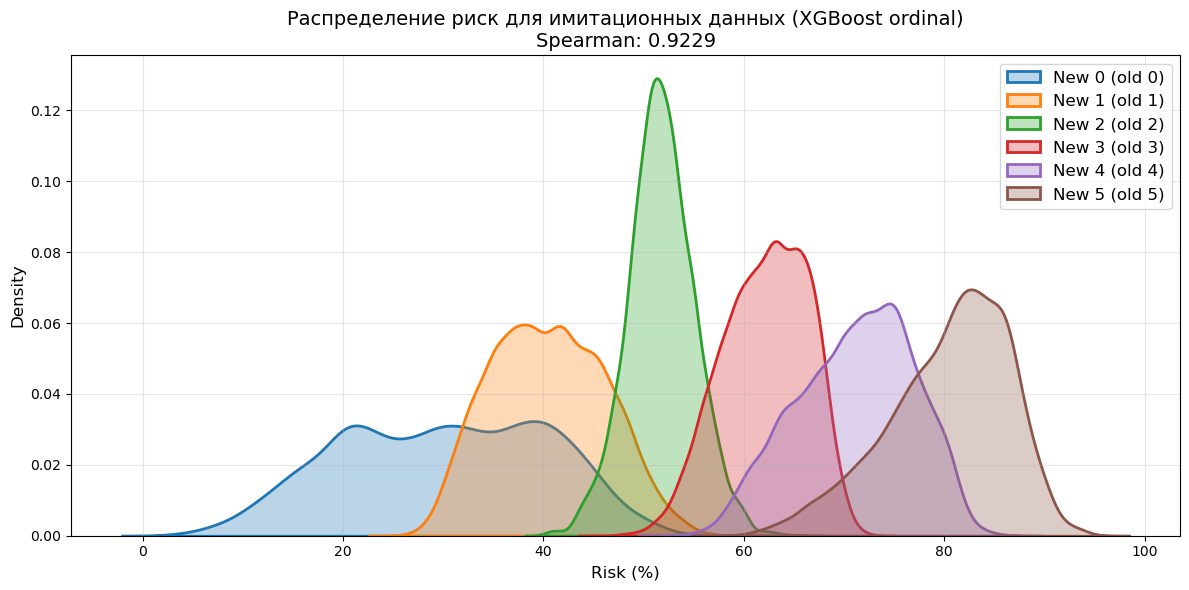

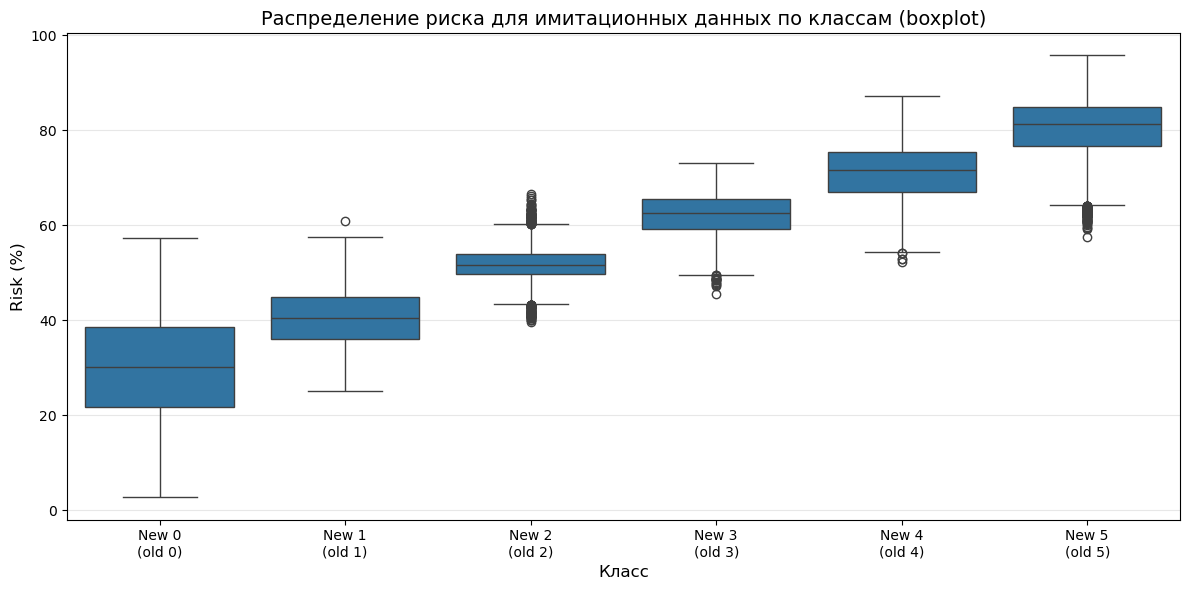

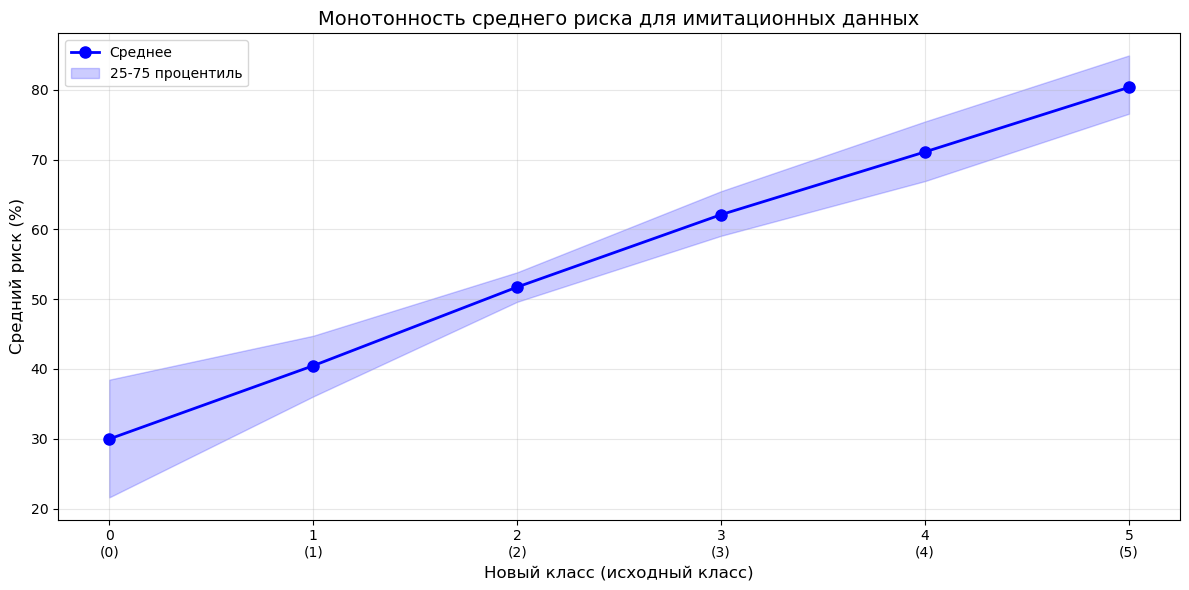

In [14]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

NUM_OF_FEATURES = 200
RANDOM_STATE = 42
NOISE_STD = 0.1
ALPHA = 0.2

# ==================== ДАННЫЕ ====================
features_df = pd.read_csv("DATA/features/MATLAB_features_ws256_overlap75.csv")

with open("DATA/rfecv_results/rfecv_threshold_0.98.json", "r") as f:
    selected_features = json.load(f)["optimal_features"][:250]

X = features_df[selected_features].to_numpy(dtype=np.float32)
y_raw = features_df["Класс"].to_numpy()

# Упорядочиваем классы (сильный риск → больший индекс)
class_mapping = {val: i for i, val in enumerate(sorted(np.unique(y_raw), reverse=True))}
y = np.array([class_mapping[val] for val in y_raw])

n_classes = len(np.unique(y))

# ==================== МАСШТАБИРОВАНИЕ ====================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==================== ФИКСИРОВАННАЯ ПЕРЕСТАНОВКА ====================
fixed_perm = [0, 1, 2, 3, 4, 5]
mapping = {old: new for new, old in enumerate(fixed_perm)}
y_mapped = np.array([mapping[v] for v in y])

# ==================== ОБУЧЕНИЕ CUMULATIVE MODELS ====================
models = []

for k in range(1, n_classes):
    y_binary = (y_mapped >= k).astype(int)

    clf = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        tree_method="hist",
        n_jobs=-1
    )

    clf.fit(X_scaled, y_binary)
    models.append(clf)

# ==================== LATENT (margin) ====================
ordinal_all = np.mean(
    [m.predict(X_scaled, output_margin=True) for m in models],
    axis=0
)

o_min, o_max = ordinal_all.min(), ordinal_all.max()
ordinal_all_n = (ordinal_all - o_min) / (o_max - o_min)


# =========================================================
# REGRESSION БЛОК 
# =========================================================
y_reg = y_mapped.astype(float) + np.random.normal(
    0, NOISE_STD, size=len(y_mapped)
)

reg_model = LGBMRegressor(
    n_estimators=400,
    max_depth=10,
    random_state=RANDOM_STATE,
    verbose=-1
)

reg_model.fit(X, y_reg)

reg_all = reg_model.predict(X)

r_min, r_max = reg_all.min(), reg_all.max()
reg_all_n = (reg_all - r_min) / (r_max - r_min)


# =========================================================
# HYBRID 
# =========================================================
risk_all = 100 * (ALPHA * ordinal_all_n + (1 - ALPHA) * reg_all_n)
risk_all = np.clip(risk_all, 0, 100)


# =========================================================
# МЕТРИКИ
# =========================================================
spearman_corr, p_value = spearmanr(risk_all, y_mapped)

print(f"Spearman correlation: {spearman_corr:.4f}")
print(f"p-value: {p_value:.4e}")

inverse_mapping = {v: k for k, v in mapping.items()}
best_perm_list = [inverse_mapping[i] for i in range(n_classes)]
print("Используемая перестановка:", best_perm_list)

# ==================== СТАТИСТИКА ====================
print("\nСтатистика Latent Risk по классам:\n")

stats = []

for new_class in range(n_classes):
    data = risk_all[y_mapped == new_class]
    old_class = inverse_mapping[new_class]

    mean_val = np.mean(data)

    stats.append({
        'Новый класс': new_class,
        'Исходный класс': old_class,
        'Среднее': mean_val,
        'Std': np.std(data),
        'Медиана': np.median(data),
        '25%': np.percentile(data, 25),
        '75%': np.percentile(data, 75),
        'Минимум': np.min(data),
        'Максимум': np.max(data)
    })

    print(f"  Новый класс {new_class} (исх.{old_class}): средний риск = {mean_val:.2f}%")

stats_df = pd.DataFrame(stats)
print("\nДетальная статистика:")
display(stats_df.style.hide(axis='index').format({
    'Среднее': '{:.2f}',
    'Std': '{:.2f}',
    'Медиана': '{:.2f}',
    '25%': '{:.2f}',
    '75%': '{:.2f}',
    'Минимум': '{:.2f}',
    'Максимум': '{:.2f}'
}))

spearman_corr, p_value = spearmanr(ordinal_all, y_mapped)

# ==================== ГРАФИК 1: KDE распределение ====================
plt.figure(figsize=(12, 6))

for new_class in range(n_classes):
    data = risk_all[y_mapped == new_class]
    old_class = inverse_mapping[new_class]
    
    sns.kdeplot(
        data,
        label=f'New {new_class} (old {old_class})',
        fill=True,
        alpha=0.3,
        linewidth=2
    )
plt.xlabel("Risk (%)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title(f"Распределение риск для имитационных данных (XGBoost ordinal)\nSpearman: {spearman_corr:.4f}", fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('APPLICATIONS/risk_distribution_xgb.png', dpi=400, bbox_inches='tight')
plt.show()

# ==================== ГРАФИК 2: Boxplot ====================
plt.figure(figsize=(12, 6))

data_for_box = []
labels_for_box = []

for new_class in range(n_classes):
    data_for_box.extend(risk_all[y_mapped == new_class])
    old_class = inverse_mapping[new_class]
    labels_for_box.extend(
        [f'New {new_class}\n(old {old_class})'] * sum(y_mapped == new_class)
    )

df_box = pd.DataFrame({'Class': labels_for_box, 'Risk': data_for_box})

sns.boxplot(data=df_box, x='Class', y='Risk')

plt.title('Распределение риска для имитационных данных по классам (boxplot)', fontsize=14)
plt.ylabel('Risk (%)', fontsize=12)
plt.xlabel('Класс', fontsize=12)
plt.grid(alpha=0.3, axis='y')

plt.tight_layout()
# plt.savefig('APPLICATIONS/risk_boxplot_xgb.png', dpi=400, bbox_inches='tight')
plt.show()

# ==================== ГРАФИК 3: Монотонность среднего риска ====================
plt.figure(figsize=(12, 6))

means = [np.mean(risk_all[y_mapped == c]) for c in range(n_classes)]
new_classes = range(n_classes)
old_labels = [f"{c}\n({inverse_mapping[c]})" for c in new_classes]

plt.plot(new_classes, means, 'o-', linewidth=2, markersize=8, color='blue', label='Среднее')

# Добавляем доверительный интервал (25-75 процентили)
plt.fill_between(
    new_classes,
    [np.percentile(risk_all[y_mapped == c], 25) for c in new_classes],
    [np.percentile(risk_all[y_mapped == c], 75) for c in new_classes],
    alpha=0.2,
    color='blue',
    label='25-75 процентиль'
)

plt.xticks(new_classes, old_labels)
plt.xlabel('Новый класс (исходный класс)', fontsize=12)
plt.ylabel('Средний риск (%)', fontsize=12)
plt.title('Монотонность среднего риска для имитационных данных', fontsize=14)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
# plt.savefig('APPLICATIONS/risk_monotonicity_xgb.png', dpi=400, bbox_inches='tight')
plt.show()


In [23]:
with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    selected_features = json.load(f)["optimal_features"][:200]

set_selected_features = set([i[3:] if i[0] == "a" or i[0] == "g" else i for i in selected_features ])
print(len(set_selected_features))

mag = [i for i in set_selected_features if "mag" in i]
print(mag)
print(len(mag))
set_mag = set([i[6:] for i in mag])
print(set_mag)
print(len(set_mag))

96
['mag_g_TD_Variation', 'mag_g_TD_dif_dif_Min', 'mag_a_TD_dif_dif_CumsumMin', 'mag_g_TD_dif_Min', 'mag_a_TD_dif_dif_L1', 'mag_a_TD_Min', 'mag_g_TD_Integral', 'mag_a_TD_dif_Min', 'mag_g_TD_dif_dif_Std', 'mag_a_TD_dif_Median', 'mag_g_TD_dif_dif_Integral', 'mag_a_TD_CumsumMin', 'mag_g_TD_dif_CumsumMin', 'mag_a_TD_dif_dif_Ptp', 'mag_g_TD_CumsumMin', 'mag_a_TD_Std', 'mag_g_TD_dif_Median', 'mag_a_TD_dif_dif_CumsumMax', 'mag_g_TD_dif_dif_CumsumRange', 'mag_a_TD_Variation', 'mag_a_TD_IntegralSq', 'mag_g_TD_dif_Max', 'mag_g_TD_dif_dif_Median', 'mag_g_TD_Min', 'mag_g_TD_dif_RMS', 'mag_g_TD_dif_dif_OutlierCount', 'mag_g_TD_dif_dif_CumsumMin']
27
{'TD_dif_CumsumMin', 'TD_dif_Min', 'TD_dif_dif_CumsumMin', 'TD_Min', 'TD_Integral', 'TD_IntegralSq', 'TD_dif_dif_Min', 'TD_dif_dif_Ptp', 'TD_CumsumMin', 'TD_dif_dif_OutlierCount', 'TD_dif_dif_Std', 'TD_dif_dif_L1', 'TD_Std', 'TD_dif_dif_Median', 'TD_dif_dif_CumsumRange', 'TD_dif_dif_Integral', 'TD_Variation', 'TD_dif_Median', 'TD_dif_dif_CumsumMax', 'TD

In [24]:
set_selected_features

{'FD_CumsumRange',
 'FD_EnergyAbove10Hz',
 'FD_EnergySpectralBandwidth',
 'FD_MeanAmpAbove10Hz',
 'FD_Median',
 'FD_Min',
 'FD_StdAmpAbove10Hz',
 'FD_Variation',
 'FD_dif_CumsumMax',
 'FD_dif_CumsumMin',
 'FD_dif_CumsumRange',
 'FD_dif_EnergyAbove10Hz',
 'FD_dif_EnergySpectralBandwidth',
 'FD_dif_EnergySpectralCentroid',
 'FD_dif_Integral',
 'FD_dif_Max',
 'FD_dif_MeanAmpAbove10Hz',
 'FD_dif_Median',
 'FD_dif_StdAmpAbove10Hz',
 'FD_dif_Variation',
 'FD_dif_dif_CumsumMin',
 'FD_dif_dif_EnergyAbove10Hz',
 'FD_dif_dif_EnergySpectralBandwidth',
 'FD_dif_dif_EnergySpectralCentroid',
 'FD_dif_dif_MeanAmpAbove10Hz',
 'FD_dif_dif_Median',
 'FD_dif_dif_Min',
 'FD_dif_dif_Variation',
 'TD_CumsumMax',
 'TD_CumsumMin',
 'TD_Integral',
 'TD_IntegralSq',
 'TD_Max',
 'TD_Median',
 'TD_Min',
 'TD_OutlierCount',
 'TD_P25',
 'TD_P75',
 'TD_Ptp',
 'TD_RMS',
 'TD_Variation',
 'TD_dif_CumsumMax',
 'TD_dif_CumsumMin',
 'TD_dif_CumsumRange',
 'TD_dif_L1',
 'TD_dif_Max',
 'TD_dif_Median',
 'TD_dif_Min',
 'TD_

In [25]:
print(len(['FD_CumsumRange',
 'FD_EnergyAbove10Hz',
 'FD_EnergySpectralBandwidth',
 'FD_MeanAmpAbove10Hz',
 'FD_Median',
 'FD_Min',
 'FD_StdAmpAbove10Hz',
 'FD_Variation',
 'FD_dif_CumsumMax',
 'FD_dif_CumsumMin',
 'FD_dif_CumsumRange',
 'FD_dif_EnergyAbove10Hz',
 'FD_dif_EnergySpectralBandwidth',
 'FD_dif_EnergySpectralCentroid',
 'FD_dif_Integral',
 'FD_dif_Max',
 'FD_dif_MeanAmpAbove10Hz',
 'FD_dif_Median',
 'FD_dif_StdAmpAbove10Hz',
 'FD_dif_Variation',
 'FD_dif_dif_CumsumMin',
 'FD_dif_dif_EnergyAbove10Hz',
 'FD_dif_dif_EnergySpectralBandwidth',
 'FD_dif_dif_EnergySpectralCentroid',
 'FD_dif_dif_MeanAmpAbove10Hz',
 'FD_dif_dif_Median',
 'FD_dif_dif_Min',
 'FD_dif_dif_Variation',
 'TD_CumsumMax',
 'TD_CumsumMin',
 'TD_Integral',
 'TD_IntegralSq',
 'TD_Max',
 'TD_Median',
 'TD_Min',
 'TD_OutlierCount',
 'TD_P25',
 'TD_P75',
 'TD_Ptp',
 'TD_RMS',
 'TD_Variation',
 'TD_dif_CumsumMax',
 'TD_dif_CumsumMin',
 'TD_dif_CumsumRange',
 'TD_dif_L1',
 'TD_dif_Max',
 'TD_dif_Median',
 'TD_dif_Min',
 'TD_dif_OutlierCount',
 'TD_dif_P25',
 'TD_dif_P75',
 'TD_dif_Ptp',
 'TD_dif_RMS',
 'TD_dif_Std',
 'TD_dif_Variation',
 'TD_dif_dif_CumsumFinal',
 'TD_dif_dif_CumsumMax',
 'TD_dif_dif_CumsumMin',
 'TD_dif_dif_Integral',
 'TD_dif_dif_IntegralSq',
 'TD_dif_dif_L1',
 'TD_dif_dif_Max',
 'TD_dif_dif_Median',
 'TD_dif_dif_Min',
 'TD_dif_dif_OutlierCount',
 'TD_dif_dif_P25',
 'TD_dif_dif_P75',
 'TD_dif_dif_Ptp',
 'TD_dif_dif_Variation']))

69


In [26]:
69 * 6

414